In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy import stats
import pingouin

import numpy as np
import pandas as pd
import os
import pickle
import statistics
import csv

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

from statsmodels.stats.multitest import multipletests
from scipy.stats import linregress

import matplotlib.pyplot as plt
from matplotlib.pyplot import gcf
import matplotlib
from matplotlib import cm, colors
import seaborn as sns

from gseapy.plot import barplot, dotplot
import gseapy as gp
from gseapy import Msigdb

matplotlib.rc('pdf', fonttype=42)

sns.set(font_scale=1.5)
sns.set_style("ticks")

In [2]:
# Parameters
hue_order=['Biopsy', 'Resection']

In [3]:
# Import data

raw = pd.read_csv('../counts_080725.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw = raw.iloc[:,5:]
# Change column names
raw.columns = raw.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
raw.head()

,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,BSSE_QGF_129474,BSSE_QGF_129475,BSSE_QGF_129476,BSSE_QGF_129477,BSSE_QGF_129478,BSSE_QGF_129479,...,BSSE_QGF_182105,BSSE_QGF_182106,BSSE_QGF_182107,BSSE_QGF_182108,BSSE_QGF_182109,BSSE_QGF_182110,BSSE_QGF_182111,BSSE_QGF_55728,BSSE_QGF_55730,BSSE_QGF_55744
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,298,531,285,307,158,589,289,268,169,243,...,231,261,1579,276,1251,445,279,127,491,217
ENSG00000279928,1,1,0,3,0,1,1,22,2,1,...,3,0,2,1,4,0,0,2,4,1
ENSG00000228037,13,11,10,0,12,13,24,17,3,2,...,2,5,43,5,23,8,3,14,16,12
ENSG00000142611,40,9,50,5,18,20,92,66,19,10,...,79,13,6,4,67,5,5,4,73,66
ENSG00000284616,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6


In [4]:
# New sample mapping with clinical features
meta = pd.read_csv('../sample_mapping_BvR.csv')
# We only do HCC
meta = meta[meta['Tumor diagnosis'] == 'HCC']
# Only take patients were we have all transcriptome samples
rna_cols = ['Biopsy_nt_transcriptome', 'Biopsy_tu_transcriptome',
            'Resection_nt_transcriptome', 'Resection_tu_transcriptome']
meta = meta.dropna(subset=rna_cols)
meta.head()



,Patient ID,Biopsy_nt_transcriptome,Biopsy_tu_transcriptome,Resection_nt_transcriptome,Resection_tu_transcriptome,Biopsy_nt_proteome,Biopsy_tu_proteome,Resection_nt_protome,Resection_tu_protome,Biopsy_nt_phospho,...,Biopsy_nt_stroma,Resection_nt_stroma,Biopsy_tu_tumor,Resection_tu_tumor,Biopsy_tu_stroma,Resection_tu_stroma,Biopsy_tu_necrosis,Resection_tu_necrosis,Biopsy_tu_nontumor,Resection_tu_nontumor
3,B,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,NaN,NaN,NaN,NaN,NaN,...,16.0,6.0,86.0,99.0,8.0,0.0,0.0,1.0,5.0,0.0
5,C,BSSE_QGF_145480,BSSE_QGF_145481,BSSE_QGF_182091,BSSE_QGF_182092,001_BR-LF-3_C21,002_BR-LF-3_C21,041_BR-LF-3_C21,042rr_BR-LF-3_C21,001_BR-LF-3P_PO4_C21,...,38.0,9.0,92.0,98.0,8.0,0.0,0.0,2.0,0.0,0.0
7,D,BSSE_QGF_182052,BSSE_QGF_182053,BSSE_QGF_182082,BSSE_QGF_182083,011_BR-LF-3_C21,012_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,011_BR-LF-3P_PO4_C21,...,16.0,13.0,47.0,97.0,29.0,3.0,0.0,0.0,24.0,0.0
9,E,BSSE_QGF_145476,BSSE_QGF_145477,BSSE_QGF_145478,BSSE_QGF_145479,075_BR-LF-3_C21,076_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,075_BR-LF-3P_PO4_C21,...,7.0,10.0,61.0,99.0,19.0,1.0,5.0,0.0,15.0,0.0
11,F,BSSE_QGF_145472,BSSE_QGF_145473,BSSE_QGF_145474,BSSE_QGF_145475,077_BR-LF-3_C21,078_BR-LF-3_C21,089_BR-LF-3_C21,090_BR-LF-3_C21,077_BR-LF-3P_PO4_C21,...,1.0,3.0,75.0,96.0,10.0,4.0,14.0,0.0,0.0,0.0


In [5]:
# Check if we have all rna seq samples in the counts table
found = []
for group in rna_cols:
    for seq_id in meta[group]:
        if seq_id in raw.columns:
            found.append(seq_id)
        else:
            print('missing:', seq_id)

In [6]:
# Extras
extras = []
for seq_id in raw.columns:
    if seq_id in found:
        continue
    else:
        print('extra:', seq_id)
        extras.append(seq_id)
raw_ = raw.drop(extras, axis=1)

extra: BSSE_QGF_145457
extra: BSSE_QGF_145458
extra: BSSE_QGF_145465
extra: BSSE_QGF_145466
extra: BSSE_QGF_182046
extra: BSSE_QGF_182047
extra: BSSE_QGF_182048
extra: BSSE_QGF_182049
extra: BSSE_QGF_182056
extra: BSSE_QGF_182057
extra: BSSE_QGF_182080
extra: BSSE_QGF_182081
extra: BSSE_QGF_182087
extra: BSSE_QGF_182088
extra: BSSE_QGF_182108
extra: BSSE_QGF_182109


In [7]:
# Import metadata
meta_old = pd.read_csv('sample_mapping_transcriptome.csv')
#meta = meta[meta.Remove == 'no']
meta_old.head()

,Sex,Sample_type,Tissue_type_A,Tissue_type_B,RNA_seq_code,Patient_ID,read_length,New,Remove,Patient,Batch
0,M,Biopsy,Non-tumor,Liver,BSSE_QGF_129466,2098537,51,NEW SAMPLE,no,B,1
1,M,Biopsy,Tumor,HCC,BSSE_QGF_129467,2098537,51,NEW SAMPLE,no,B,1
2,M,Resection,Non-tumor,Liver,BSSE_QGF_129468,2098537,51,NEW SAMPLE,no,B,1
3,M,Resection,Tumor,HCC,BSSE_QGF_129469,2098537,51,NEW SAMPLE,no,B,1
4,M,Biopsy,Non-tumor,Liver,BSSE_QGF_129474,3263809,51,NEW SAMPLE,no,K,1


In [8]:
# We need the batch information - prepare a mapping
meta_old.index = meta_old.RNA_seq_code
meta_old.head()

,Sex,Sample_type,Tissue_type_A,Tissue_type_B,RNA_seq_code,Patient_ID,read_length,New,Remove,Patient,Batch
RNA_seq_code,,,,,,,,,,,
BSSE_QGF_129466,M,Biopsy,Non-tumor,Liver,BSSE_QGF_129466,2098537,51,NEW SAMPLE,no,B,1
BSSE_QGF_129467,M,Biopsy,Tumor,HCC,BSSE_QGF_129467,2098537,51,NEW SAMPLE,no,B,1
BSSE_QGF_129468,M,Resection,Non-tumor,Liver,BSSE_QGF_129468,2098537,51,NEW SAMPLE,no,B,1
BSSE_QGF_129469,M,Resection,Tumor,HCC,BSSE_QGF_129469,2098537,51,NEW SAMPLE,no,B,1
BSSE_QGF_129474,M,Biopsy,Non-tumor,Liver,BSSE_QGF_129474,3263809,51,NEW SAMPLE,no,K,1


In [9]:
# Add Gene Biotype Names
with open('../../../ensemble_mappings_biotype.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_bt = raw_.reset_index(names='Geneid').copy()
    
df_bt['Biotype'] = df_bt['Geneid'].map(loaded_dict)
df_bt.Biotype = df_bt.Biotype.replace('', np.nan)
df_bt.index = df_bt.Geneid
df_bt = df_bt.drop('Geneid', axis=1)

In [10]:
df_bt.head()

,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,BSSE_QGF_129474,BSSE_QGF_129475,BSSE_QGF_129476,BSSE_QGF_129477,BSSE_QGF_129478,BSSE_QGF_129479,...,BSSE_QGF_182104,BSSE_QGF_182105,BSSE_QGF_182106,BSSE_QGF_182107,BSSE_QGF_182110,BSSE_QGF_182111,BSSE_QGF_55728,BSSE_QGF_55730,BSSE_QGF_55744,Biotype
Geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,298,531,285,307,158,589,289,268,169,243,...,201,231,261,1579,445,279,127,491,217,protein_coding
ENSG00000279928,1,1,0,3,0,1,1,22,2,1,...,0,3,0,2,0,0,2,4,1,transcribed_unprocessed_pseudogene
ENSG00000228037,13,11,10,0,12,13,24,17,3,2,...,0,2,5,43,8,3,14,16,12,lncRNA
ENSG00000142611,40,9,50,5,18,20,92,66,19,10,...,13,79,13,6,5,5,4,73,66,protein_coding
ENSG00000284616,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,6,lncRNA


In [11]:
# Take only protein coding genes
df_pc = df_bt[df_bt.Biotype == 'protein_coding'].copy()
df_pc.index.name = None
df_pc.shape

(20056, 65)

In [12]:
meta.columns

Index(['Patient ID', 'Patient Nr', 'Biopsy_nt_transcriptome',
       'Biopsy_tu_transcriptome', 'Resection_nt_transcriptome',
       'Resection_tu_transcriptome', 'Biopsy_nt_proteome',
       'Biopsy_tu_proteome', 'Resection_nt_protome', 'Resection_tu_protome',
       'Biopsy_nt_phospho', 'Biopsy_tu_phospho', 'Resection_nt_phospho',
       'Resection_tu_phospho', 'Age', 'Sex', 'PreBx_MELD', 'PreBx_ALAT',
       'PreBx_ASAT', 'PreBx_GGT', 'PreBx_AP', 'PreBx_Albumin',
       'PreBx_Bilirubin', 'PreBx_Quick', 'PreBx_Hb', 'PreBx_Lc', 'PreBx_Tc',
       'PreBx_CRP', 'PreBx_AFP', 'PreOP_MELD', 'PreOP_ALAT', 'PreOP_ASAT',
       'PreOP_GGT', 'PreOP_AP', 'PreOP_Albumin', 'PreOP_Bilirubin',
       'PreOP_Quick', 'PreOP_Hb', 'PreOP_Lc', 'PreOP_Tc', 'PreOP_CRP',
       'PreOP_AFP', 'CHILD', 'BCLC', 'Nr of nodules', 'Max nodule size',
       'Time between resection and biopsy',
       'Total surgery time = ischemia time', 'Tumor diagnosis',
       'Biopsy_nt_hepatocyte', 'Resection_nt_hepatocyte',

In [13]:
meta_rna = meta.loc[:,['Patient ID', 'Biopsy_nt_transcriptome',
       'Biopsy_tu_transcriptome', 'Resection_nt_transcriptome',
       'Resection_tu_transcriptome','Age', 'Sex','Time between resection and biopsy',
       'Total surgery time = ischemia time']].copy()
meta_rna = meta_rna.melt(id_vars=['Patient ID', 'Age', 'Sex',
                                  'Time between resection and biopsy',
                                  'Total surgery time = ischemia time'],
                         value_vars=['Biopsy_nt_transcriptome',
                                     'Biopsy_tu_transcriptome', 
                                     'Resection_nt_transcriptome',
                                     'Resection_tu_transcriptome',])
meta_rna['Sample_type'] = meta_rna.variable.str.split('_').str[0]
meta_rna['Tissue'] = np.where(meta_rna.variable.str.contains('nt'), 'non-tumor', 'tumor')
meta_rna = meta_rna.drop('variable', axis=1)
meta_rna = meta_rna.rename({'value':'Seq_id', 'Total surgery time = ischemia time': 'Total surgery time',
                           'Patient ID': 'patient_id'}, axis=1)
# Map Batch from previous metadata
meta_rna['batch'] = meta_rna.Seq_id.map(meta_old.Batch)
meta_rna.batch = meta_rna.batch.fillna(1).astype(int)

# biopsy dont have surgery time
meta_rna['Total surgery time'] = np.where(meta_rna['Sample_type'] == 'Biopsy', 0, meta_rna['Total surgery time'])

# Patint C has a very long tim ebwteen Biopsy and resection
meta_rna = meta_rna[meta_rna.patient_id != 'C']

meta_rna.head()

,patient_id,Age,Sex,Time between resection and biopsy,Total surgery time,Seq_id,Sample_type,Tissue,batch
0,B,59,M,43,0.0,BSSE_QGF_129466,Biopsy,non-tumor,1
2,D,70,F,29,0.0,BSSE_QGF_182052,Biopsy,non-tumor,2
3,E,79,M,31,0.0,BSSE_QGF_145476,Biopsy,non-tumor,1
4,F,49,M,11,0.0,BSSE_QGF_145472,Biopsy,non-tumor,1
5,H,69,F,20,0.0,BSSE_QGF_129476,Biopsy,non-tumor,1


## Split samples by tissue because:
### We are not comparing tumor vs. normal directly and only care about effects within a group (e.g., sampling method effect within tumor).

### There are very strong biological differences (like tumor heterogeneity, immune infiltration, etc.) that:

####     - Skew global mean-dispersion relationships.

####     - Dominate PCA, making sampling method differences harder to detect.

In [14]:
metadata = meta_rna.loc[:,['Sample_type', 'Sex', 'Age', 'Tissue',
                           'Seq_id', 'patient_id', 'batch',
                           'Time between resection and biopsy',
                           'Total surgery time']].copy()
metadata.index = metadata.Seq_id
metadata_liver = metadata[metadata.Tissue == 'non-tumor'].copy()
metadata_hcc = metadata[metadata.Tissue == 'tumor'].copy()


In [15]:
# QC

star_qc = pd.read_csv('star_alignment_plot.csv', index_col=0, )
star_qc.head()

,Uniquely mapped,Mapped to multiple loci,Mapped to too many loci,Unmapped: too short,Unmapped: other
Category,,,,,
BSSE_QGF_129466,87649491,36706106,191751,1594725,113909
BSSE_QGF_129467,108652373,14717948,127614,1880319,150426
BSSE_QGF_129468,88220083,26541092,190914,1339382,116468
BSSE_QGF_129469,85237280,12956213,113344,1253497,79587
BSSE_QGF_129474,68773205,55606441,190207,1755783,88421


In [16]:
star_qc = star_qc[star_qc.index.isin(metadata.index)]
star_qc

,Uniquely mapped,Mapped to multiple loci,Mapped to too many loci,Unmapped: too short,Unmapped: other
Category,,,,,
BSSE_QGF_129466,87649491,36706106,191751,1594725,113909
BSSE_QGF_129467,108652373,14717948,127614,1880319,150426
BSSE_QGF_129468,88220083,26541092,190914,1339382,116468
BSSE_QGF_129469,85237280,12956213,113344,1253497,79587
BSSE_QGF_129474,68773205,55606441,190207,1755783,88421
BSSE_QGF_129475,87183026,21271928,130143,1319591,43986
BSSE_QGF_129476,74062522,10759364,119903,1129047,120662
BSSE_QGF_129477,75463622,31480543,154065,1104967,75831
BSSE_QGF_129478,81635781,8941266,126590,1302845,82575


In [17]:
metadata_qc = pd.concat([metadata, star_qc], axis=1)
metadata_qc.columns


Index(['Sample_type', 'Sex', 'Age', 'Tissue', 'Seq_id', 'patient_id', 'batch',
       'Time between resection and biopsy', 'Total surgery time',
       'Uniquely mapped', 'Mapped to multiple loci', 'Mapped to too many loci',
       'Unmapped: too short', 'Unmapped: other'],
      dtype='object')

In [18]:
metadata_qc_ = metadata_qc.loc[:,['Sample_type', 'Uniquely mapped', 'Mapped to multiple loci', 'Mapped to too many loci',
       'Unmapped: too short', 'Unmapped: other']].reset_index().copy()

metadata_qc_ = metadata_qc_.melt(id_vars=['index', 'Sample_type'])
metadata_qc_.head()

,index,Sample_type,variable,value
0,BSSE_QGF_129466,Biopsy,Uniquely mapped,87649491.0
1,BSSE_QGF_182052,Biopsy,Uniquely mapped,56339879.0
2,BSSE_QGF_145476,Biopsy,Uniquely mapped,32130365.0
3,BSSE_QGF_145472,Biopsy,Uniquely mapped,36361834.0
4,BSSE_QGF_129476,Biopsy,Uniquely mapped,74062522.0


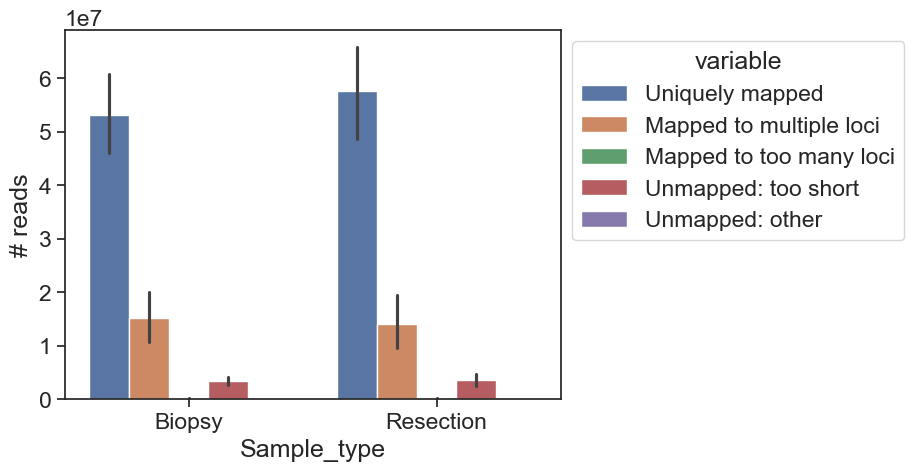

In [19]:
ax = sns.barplot(data=metadata_qc_, x='Sample_type', y='value', hue='variable')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.ylabel('# reads')

plt.savefig('figures/Transcriptomics_qc.pdf', bbox_inches='tight', dpi=300)

In [20]:
metadata_qc_nona = metadata_qc_.dropna(axis=0).copy()

In [21]:
metadata_qc_nona

,index,Sample_type,variable,value
0,BSSE_QGF_129466,Biopsy,Uniquely mapped,87649491.0
1,BSSE_QGF_182052,Biopsy,Uniquely mapped,56339879.0
2,BSSE_QGF_145476,Biopsy,Uniquely mapped,32130365.0
3,BSSE_QGF_145472,Biopsy,Uniquely mapped,36361834.0
4,BSSE_QGF_129476,Biopsy,Uniquely mapped,74062522.0
...,...,...,...,...
294,BSSE_QGF_182085,Resection,Unmapped: other,71969.0
295,BSSE_QGF_182101,Resection,Unmapped: other,121692.0
297,BSSE_QGF_182103,Resection,Unmapped: other,47385.0
298,BSSE_QGF_182105,Resection,Unmapped: other,30113.0


In [22]:
res_list = []
for var in metadata_qc_nona.variable.unique():
    subset = metadata_qc_nona[metadata_qc_nona.variable == var]
    print(var)
    res = stats.ttest_ind(subset[subset.Sample_type == 'Biopsy'].value, subset[subset.Sample_type == 'Resection'].value)
    print(res)
    print('\n')
    res_list.append(var)
    res_list.append(res)

with open('transcriptomics_qc_ttest.csv', 'w', newline='') as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(res_list)

Uniquely mapped
TtestResult(statistic=np.float64(-0.7586414026256468), pvalue=np.float64(0.45130600677696997), df=np.float64(55.0))


Mapped to multiple loci
TtestResult(statistic=np.float64(0.29300987910485654), pvalue=np.float64(0.7706172868267169), df=np.float64(55.0))


Mapped to too many loci
TtestResult(statistic=np.float64(-1.052821202323181), pvalue=np.float64(0.29702648153905065), df=np.float64(55.0))


Unmapped: too short
TtestResult(statistic=np.float64(-0.3468272536457285), pvalue=np.float64(0.7300446277956899), df=np.float64(55.0))


Unmapped: other
TtestResult(statistic=np.float64(-0.6236043963098138), pvalue=np.float64(0.5354652219005235), df=np.float64(55.0))




# Liver

In [23]:
metadata_liver.columns

Index(['Sample_type', 'Sex', 'Age', 'Tissue', 'Seq_id', 'patient_id', 'batch',
       'Time between resection and biopsy', 'Total surgery time'],
      dtype='object')

In [24]:
df_pc_liver = df_pc.loc[:,metadata_liver.index].copy()

In [25]:
# Filtering

# Create a copy to work on
df_pc_liver_f = df_pc_liver.copy()

# Apply the filter criteria
for col in df_pc_liver_f.columns:
    df_pc_liver_f[col] = np.where(df_pc_liver_f[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_pc_liver_f['Keep'] = np.where(df_pc_liver_f.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_pc_liver_f[df_pc_liver_f.Keep].index

# Return only the rows that were determined to be kept during fitting
df_pc_liver_f = df_pc_liver.loc[keep_indices_].copy()

In [26]:
df_pc_liver_f.shape

(15723, 30)

<Axes: xlabel='total_reads', ylabel='Sample_type'>

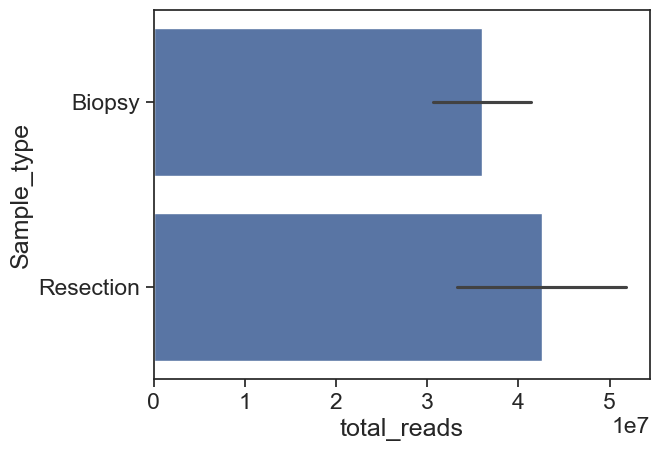

In [27]:
metadata_liver_ = metadata_liver.copy()
metadata_liver_['total_reads'] = df_pc_liver_f.sum()

sns.barplot(data=metadata_liver_, y='Sample_type', x='total_reads')

In [28]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_liver_f.T,
    metadata=metadata_liver,
    # design_factors=[Sex + batch + patient_id], # Sex as covariate
    design="~patient_id + Sample_type",
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_liver_f.T)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_liver_f.T.index, columns=df_pc_liver_f.T.columns
)
df_liver = transformed_counts.T

Fitting size factors...
... done in 0.05 seconds.

Fitting size factors...
... done in 0.05 seconds.



Using None as control genes, passed at DeseqDataSet initialization
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 11.78 seconds.



In [29]:
df_liver.head()

Seq_id,BSSE_QGF_129466,BSSE_QGF_182052,BSSE_QGF_145476,BSSE_QGF_145472,BSSE_QGF_129476,BSSE_QGF_182072,BSSE_QGF_182064,BSSE_QGF_129474,BSSE_QGF_145460,BSSE_QGF_182054,...,BSSE_QGF_182106,BSSE_QGF_182098,BSSE_QGF_129478,BSSE_QGF_145462,BSSE_QGF_182084,BSSE_QGF_182100,BSSE_QGF_129482,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182110
ENSG00000160072,7.628677,7.220001,7.157348,7.057075,7.795695,7.794800,7.907571,7.261420,7.747785,7.717703,...,7.629980,8.297720,7.192120,7.862069,8.123593,7.500284,7.328699,7.594164,8.021319,8.026734
ENSG00000142611,5.768085,5.059225,4.347859,5.092045,6.565460,4.967678,4.640026,5.477991,6.177095,4.643611,...,5.234824,5.560829,5.437577,6.074409,5.186388,4.347859,4.914741,5.311009,5.522956,4.849865
ENSG00000157911,7.655978,7.186387,7.603541,8.785904,7.243597,8.304344,8.260630,7.970926,7.619202,8.255398,...,7.830879,7.353673,7.192120,7.220063,7.595013,4.347859,7.284435,6.598707,7.872742,7.437269
ENSG00000142655,8.628060,8.388120,8.684634,9.166289,8.352413,8.970732,8.782465,8.872192,8.429772,8.515360,...,8.756878,8.411060,7.857375,8.539144,8.304767,7.983086,7.719221,8.359479,8.557217,8.193970
ENSG00000149527,6.847492,5.647802,5.967643,5.704994,6.369002,6.500375,7.658777,7.456830,6.308577,5.770824,...,5.909195,7.420427,5.612268,6.722535,6.072189,5.839284,5.819443,6.106631,6.127828,7.018764


<Axes: xlabel='total_reads_vst', ylabel='Sample_type'>

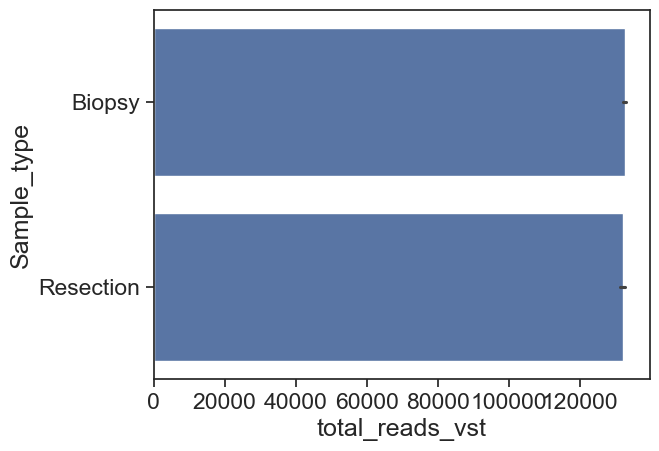

In [30]:
metadata_liver_['total_reads_vst'] = df_liver.sum()

sns.barplot(data=metadata_liver_, y='Sample_type', x='total_reads_vst')

In [31]:
df_liver_pca = df_liver.copy()
df_liver_pca['expression_std'] = df_liver_pca.std(axis=1)
df_liver_pca = df_liver_pca.sort_values('expression_std', ascending=False)
df_liver_pca = df_liver_pca.iloc[:500,:-1]
df_liver_pca.head()

Seq_id,BSSE_QGF_129466,BSSE_QGF_182052,BSSE_QGF_145476,BSSE_QGF_145472,BSSE_QGF_129476,BSSE_QGF_182072,BSSE_QGF_182064,BSSE_QGF_129474,BSSE_QGF_145460,BSSE_QGF_182054,...,BSSE_QGF_182106,BSSE_QGF_182098,BSSE_QGF_129478,BSSE_QGF_145462,BSSE_QGF_182084,BSSE_QGF_182100,BSSE_QGF_129482,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182110
ENSG00000147604,6.555213,14.035627,6.242648,6.493995,6.691017,13.685604,13.394078,6.457229,6.465010,13.862060,...,13.942972,13.443774,6.378174,6.381766,13.882206,13.919158,6.535788,13.486119,14.046544,14.044459
ENSG00000177954,6.805371,13.799442,6.846362,6.748122,6.797279,13.420743,13.189681,6.645736,6.832244,13.705421,...,13.783791,13.490917,6.764371,7.077262,13.892646,13.550383,6.927307,13.593341,14.095594,14.046074
ENSG00000134184,4.347859,4.347859,11.351400,4.347859,10.011931,4.347859,4.347859,4.347859,9.333991,12.156235,...,4.845178,4.347859,4.347859,8.638560,11.027767,5.839284,4.839574,4.665540,11.851586,12.212239
ENSG00000067048,10.854768,4.347859,10.745132,10.841758,4.602173,4.347859,10.849800,10.696160,4.347859,11.346462,...,4.700383,11.143230,11.485700,4.347859,11.976222,11.797078,11.362394,4.895909,11.424188,11.568021
ENSG00000129824,10.548811,4.347859,10.327064,10.868723,4.347859,4.347859,10.743794,10.563858,4.347859,10.832292,...,4.597440,10.509977,11.092960,4.347859,10.700565,10.630732,11.039562,4.665540,10.835979,11.012124


In [32]:
# scaled data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_liver_pca.T)

In [33]:
pca = PCA(n_components=2)

In [34]:
metadata_liver['Time between resection and biopsy']

Seq_id
BSSE_QGF_129466    43
BSSE_QGF_182052    29
BSSE_QGF_145476    31
BSSE_QGF_145472    11
BSSE_QGF_129476    20
BSSE_QGF_182072    30
BSSE_QGF_182064    28
BSSE_QGF_129474    27
BSSE_QGF_145460    18
BSSE_QGF_182054    15
BSSE_QGF_182066    28
BSSE_QGF_55728     10
BSSE_QGF_182070    32
BSSE_QGF_182074    19
BSSE_QGF_182076    15
BSSE_QGF_129468    43
BSSE_QGF_182082    29
BSSE_QGF_145478    31
BSSE_QGF_145474    11
BSSE_QGF_129480    20
BSSE_QGF_182106    30
BSSE_QGF_182098    28
BSSE_QGF_129478    27
BSSE_QGF_145462    18
BSSE_QGF_182084    15
BSSE_QGF_182100    28
BSSE_QGF_129482    10
BSSE_QGF_182102    32
BSSE_QGF_182104    19
BSSE_QGF_182110    15
Name: Time between resection and biopsy, dtype: int64

In [35]:
import matplotlib.colors as mcolors

norm = mcolors.LogNorm(vmin=10, vmax=240)   # log scale

In [36]:
norm

In [37]:
metadata_liver

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,batch,Time between resection and biopsy,Total surgery time
Seq_id,,,,,,,,,
BSSE_QGF_129466,Biopsy,M,59,non-tumor,BSSE_QGF_129466,B,1,43,0.0
BSSE_QGF_182052,Biopsy,F,70,non-tumor,BSSE_QGF_182052,D,2,29,0.0
BSSE_QGF_145476,Biopsy,M,79,non-tumor,BSSE_QGF_145476,E,1,31,0.0
BSSE_QGF_145472,Biopsy,M,49,non-tumor,BSSE_QGF_145472,F,1,11,0.0
BSSE_QGF_129476,Biopsy,F,69,non-tumor,BSSE_QGF_129476,H,1,20,0.0
BSSE_QGF_182072,Biopsy,F,54,non-tumor,BSSE_QGF_182072,I,2,30,0.0
BSSE_QGF_182064,Biopsy,M,77,non-tumor,BSSE_QGF_182064,J,2,28,0.0
BSSE_QGF_129474,Biopsy,M,71,non-tumor,BSSE_QGF_129474,K,1,27,0.0
BSSE_QGF_145460,Biopsy,F,66,non-tumor,BSSE_QGF_145460,L,1,18,0.0


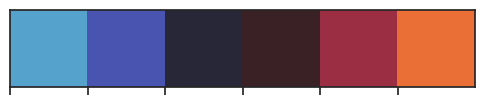

In [38]:
palette = sns.color_palette('icefire')
sns.palplot(palette)
plt.savefig('icefire_cmap.pdf')

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_15788\2499988608.py:60: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


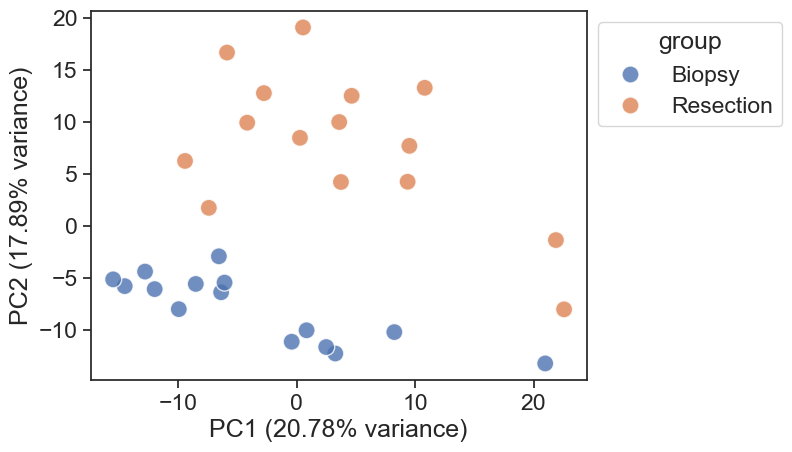

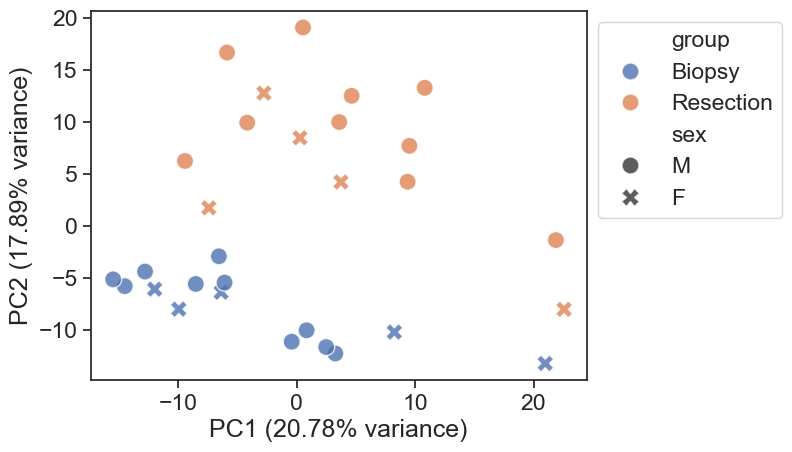

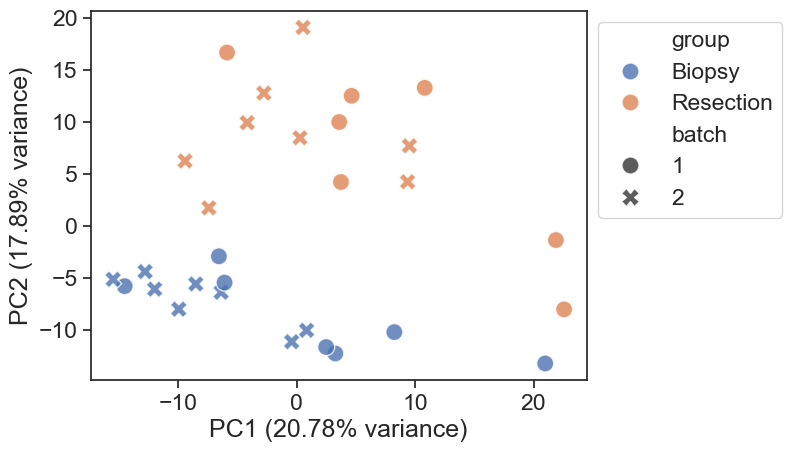

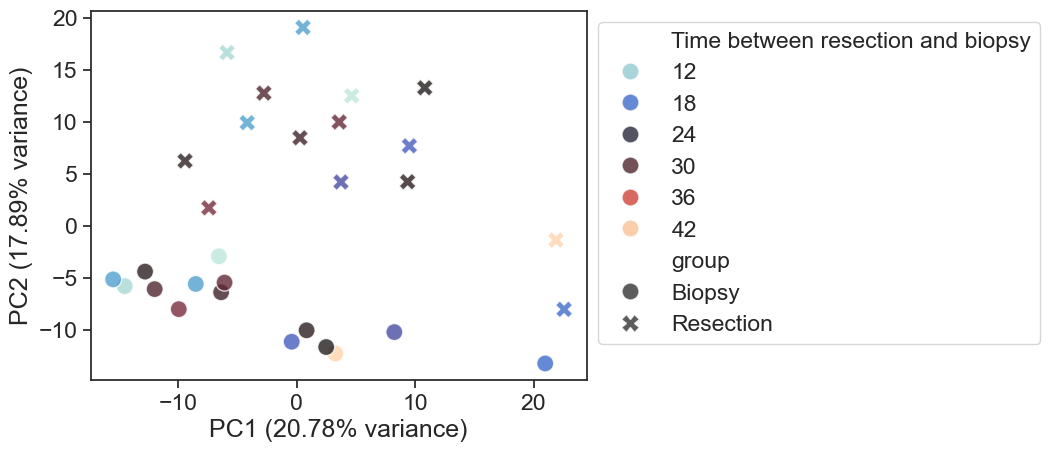

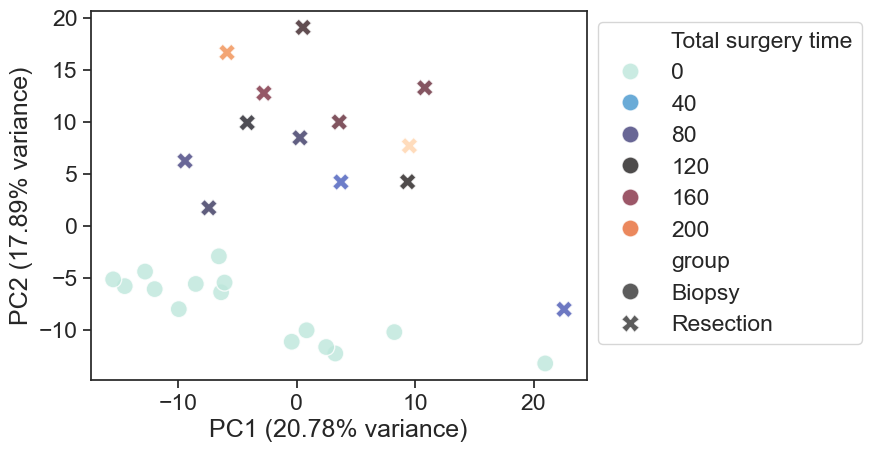

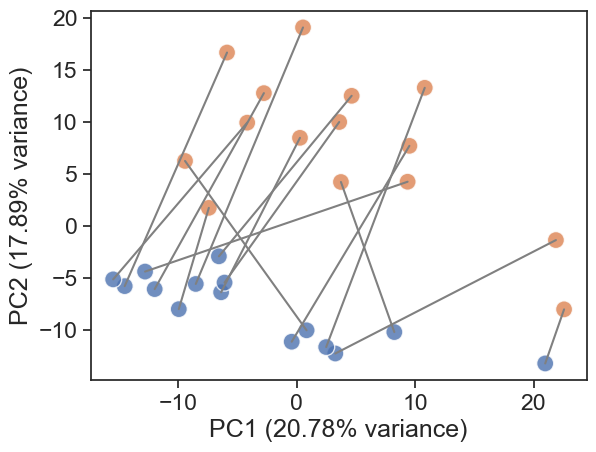

In [39]:
projections = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(projections, columns=['PC1', 'PC2'], index=df_liver_pca.columns)
df_pca['group'] = metadata_liver.Sample_type
df_pca['batch'] = metadata_liver.batch
df_pca['sex'] = metadata_liver.Sex
df_pca['patient_id'] = metadata_liver.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_liver['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_liver['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver.pdf', bbox_inches='tight', dpi=300)

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_sex.pdf', bbox_inches='tight', dpi=300)

# Batch
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='batch',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_batch.pdf', bbox_inches='tight', dpi=300)

# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_timeBvR.pdf', bbox_inches='tight', dpi=300)

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_surgerytime.pdf', bbox_inches='tight', dpi=300)

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('figures/PCA_liver_pat.pdf', bbox_inches='tight', dpi=300)

In [40]:
def r2(x, y, ax=None, **kws):
    ax = ax or plt.gca()
    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])
    ax.annotate(f'$r^2 = {r_value ** 2:.2f}$\nEq: ${slope:.2f}x{intercept:+.2f}$\np: ${p_value :.2E}$',
                xy=(.05, .95), xycoords=ax.transAxes, fontsize=8,
                color='darkred', backgroundcolor='#FFFFFF99', ha='left', va='top')

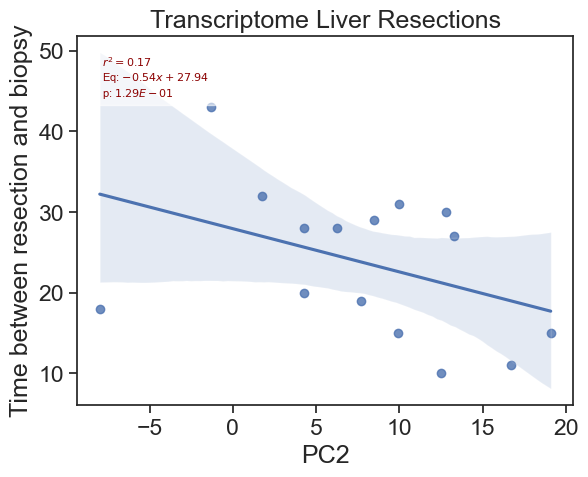

In [41]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Transcriptome Liver Resections')


plt.savefig('figures/corr_pc2_time_b_to_r.pdf', dpi=300, bbox_inches='tight')

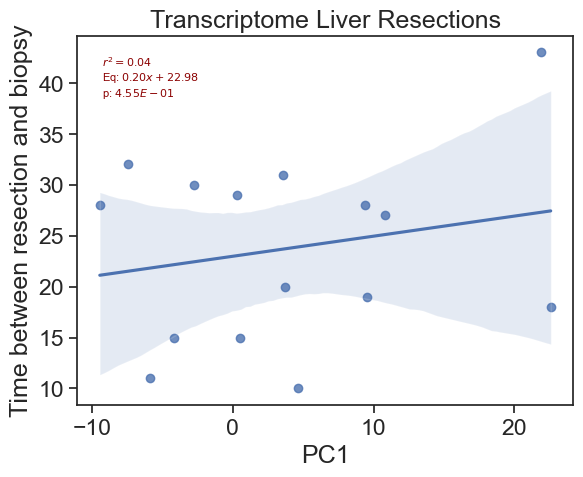

In [42]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Transcriptome Liver Resections')


plt.savefig('figures/corr_pc1_time_b_to_r.pdf', dpi=300, bbox_inches='tight')

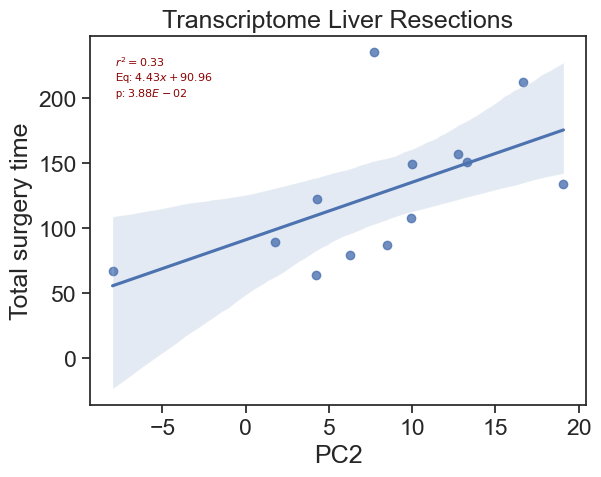

In [43]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Transcriptome Liver Resections')

plt.savefig('figures/corr_pc2_time_surgery.pdf', dpi=300, bbox_inches='tight')

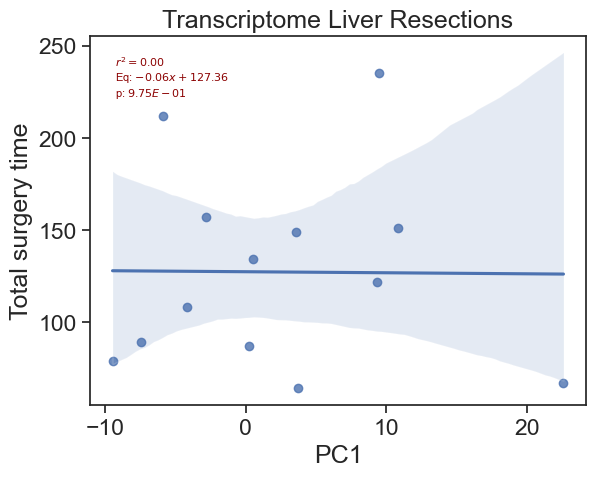

In [44]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Transcriptome Liver Resections')

plt.savefig('figures/corr_pc1_time_surgery.pdf', dpi=300, bbox_inches='tight')

In [45]:
groupA = df_pca[df_pca['group']=='Biopsy'][['PC1','PC2']]
groupB = df_pca[df_pca['group']=='Resection'][['PC1','PC2']]

t2 = pingouin.multivariate_ttest(groupA, groupB)
print(t2[['T2','F','pval']])

                   T2          F          pval
hotelling  134.508335  64.852233  4.895672e-11


In [46]:
dds.vst()

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 10.79 seconds.



In [47]:
dds.deseq2(fit_type='parametric')

Using parametric fit type.
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.05 seconds.

Fitting dispersions...
... done in 11.51 seconds.

Fitting dispersion trend curve...
... done in 0.76 seconds.

Fitting MAP dispersions...
... done in 11.75 seconds.

Fitting LFCs...
... done in 11.03 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 0 outlier genes.



In [48]:
# cooksCutoff=FALSE, independentFiltering=FALSE
ds = DeseqStats(dds, contrast=['Sample_type', 'Resection', 'Biopsy'],
                cooks_filter=False, independent_filter=False)

In [49]:
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Sample_type Resection vs Biopsy
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000160072  162.728593        0.093542  0.122348  0.764555  0.444537   
ENSG00000142611   11.950306        0.200011  0.367767  0.543853  0.586543   
ENSG00000157911  163.122437       -0.591115  0.153434 -3.852556  0.000117   
ENSG00000142655  325.321262       -0.268617  0.106888 -2.513078  0.011968   
ENSG00000149527   53.267901       -0.497611  0.241018 -2.064627  0.038958   
...                     ...             ...       ...       ...       ...   
ENSG00000278817   20.231819       -0.137893  0.265095 -0.520166  0.602948   
ENSG00000278384   19.664147       -1.035157  0.318826 -3.246780  0.001167   
ENSG00000275063   21.311922       -0.585953  0.269888 -2.171097  0.029924   
ENSG00000277856   26.629178       -0.174572  0.260247 -0.670793  0.502352   
ENSG00000271254  105.915290       -0.294578  0.192342 -1.531535  0.125637   

     

... done in 16.05 seconds.



In [50]:
df_res_liver = ds.results_df
df_res_liver['abs_diff'] = df_res_liver.log2FoldChange.abs()
df_res_liver = df_res_liver.sort_values('abs_diff', ascending=False)
df_res_liver.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff
ENSG00000125740,840.911837,9.166114,0.473588,19.354625,1.863440e-83,7.324715e-80,9.166114
ENSG00000170345,5716.198043,5.955480,0.381263,15.620413,5.286235e-55,1.038943e-51,5.955480
ENSG00000109321,32.868382,5.730060,0.728721,7.863170,3.745326e-15,4.749013e-13,5.730060
ENSG00000123358,311.474553,5.151057,0.333869,15.428389,1.054699e-53,1.842558e-50,5.151057
ENSG00000146678,14639.041145,4.723085,0.435767,10.838551,2.260234e-27,1.064461e-24,4.723085


In [51]:
# Add Gene Names
with open('../../../ensemble_mappings_gene.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_n_l = df_res_liver.reset_index(names='Geneid').copy()
    
df_n_l['Gene'] = df_n_l['Geneid'].map(loaded_dict)
df_n_l.Gene = df_n_l.Gene.replace('', np.nan)
df_n_l['Gene'] = np.where(df_n_l.Gene.isnull(), df_n_l.Geneid, df_n_l.Gene)
df_n_l.index = df_n_l.Geneid
df_n_l = df_n_l.drop('Geneid', axis=1)

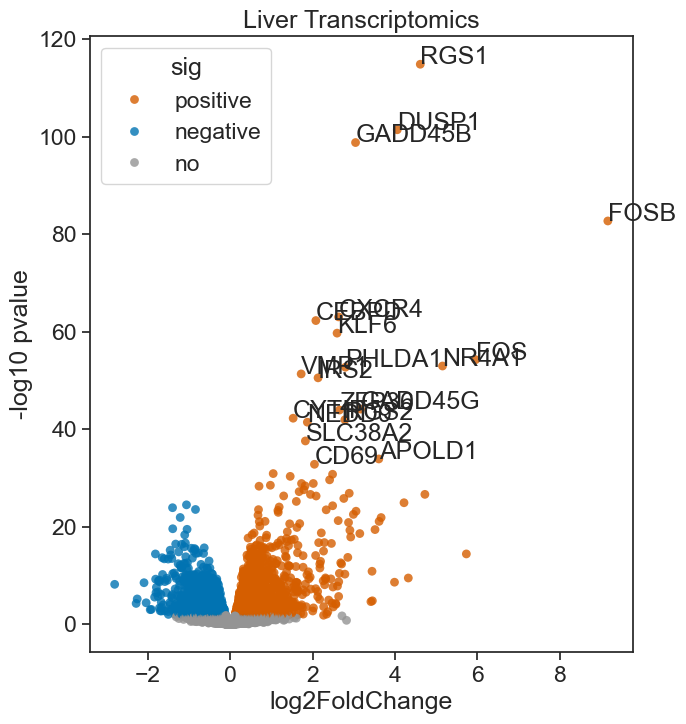

In [52]:
df_ttest_ = df_n_l.copy()

# Drop non-significant outlier
#df_ttest_ = df_ttest_[df_ttest_.Gene != 'SERPINB7']

df_ttest_['sig'] = np.where((df_ttest_['padj'] < 0.05) &\
                            (df_ttest_['log2FoldChange'] > 0), 'positive',
                    np.where((df_ttest_['padj'] < 0.05) &\
                             (df_ttest_['log2FoldChange'] < 0), 'negative', 
                                    'no'))
df_ttest_['-log10 pvalue'] = -np.log10(df_ttest_.pvalue)

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='log2FoldChange', y='-log10 pvalue',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pvalue', ascending=False)
                
most_sig['Gene'] = most_sig.index.map(loaded_dict)

for i in range(0,20):
    x = most_sig.iloc[i,:]['log2FoldChange'].item()
    y = most_sig.iloc[i,:]['-log10 pvalue'].item() + 0.05
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('Liver Transcriptomics')
#plt.show()
plt.savefig('figures/Volcano_rnaseq_liver_output.pdf', bbox_inches='tight', dpi=300)

Text(0.5, 1.0, 'FOSB')

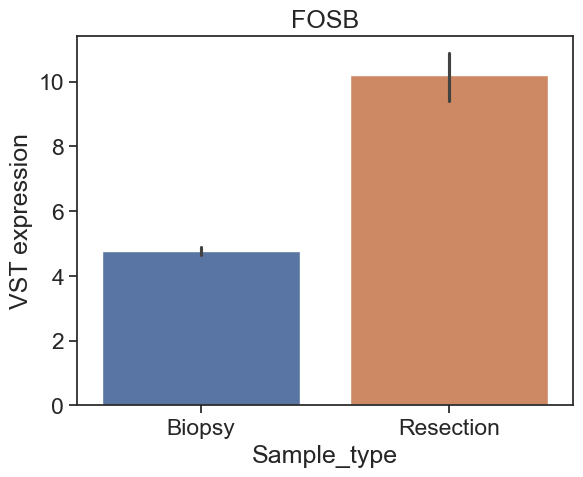

In [53]:
test_direction = pd.concat([df_liver.loc['ENSG00000125740',:], metadata_liver.Sample_type], axis=1)

sns.barplot(test_direction, x='Sample_type', y='ENSG00000125740', hue='Sample_type', hue_order=hue_order)
plt.ylabel('VST expression')
plt.title('FOSB')


Text(0.5, 0, 'FOSB')

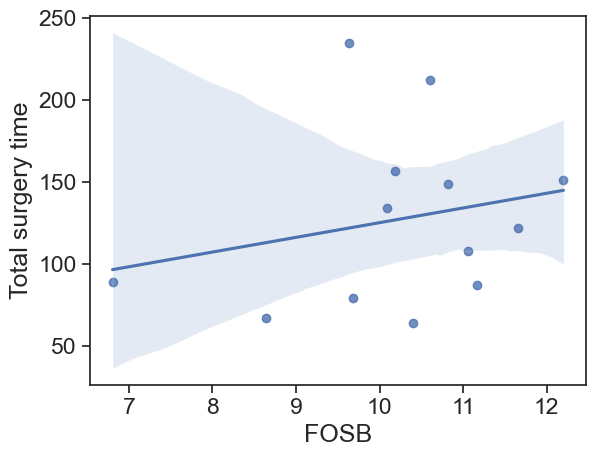

In [54]:
corr_times = pd.concat([df_liver.loc['ENSG00000125740',:], metadata_liver['Total surgery time']], axis=1)

corr_times = corr_times[corr_times['Total surgery time'] > 0]
sns.regplot(corr_times, x='ENSG00000125740', y='Total surgery time')
plt.xlabel('FOSB')

#plt.savefig('figures/FOSB_corr_surgery_time.pdf', dpi=300, bbox_inches='tight')

Text(0.5, 0, 'FOS')

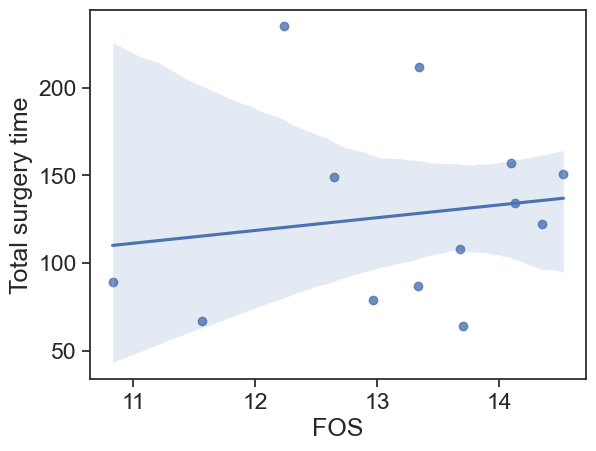

In [55]:
corr_times = pd.concat([df_liver.loc['ENSG00000170345',:], metadata_liver['Total surgery time']], axis=1)

corr_times = corr_times[corr_times['Total surgery time'] > 0]
sns.regplot(corr_times, x='ENSG00000170345', y='Total surgery time')
plt.xlabel('FOS')

#plt.savefig('figures/FOS_corr_surgery_time.pdf', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'VST expression VS total surgery time')

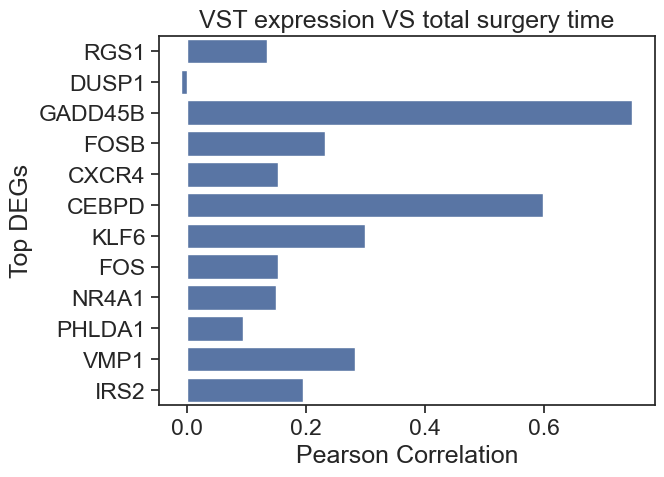

In [56]:
corr_times = pd.concat([df_liver.loc[most_sig.iloc[:12,:].index,:].T, metadata_liver['Total surgery time']], axis=1)
corr_times = corr_times[corr_times['Total surgery time'] > 0]

new_cols = corr_times.columns[:-1].map(loaded_dict).tolist()
new_cols.append('Total surgery time')
corr_times.columns = new_cols
sns.barplot(corr_times.corrwith(corr_times['Total surgery time'])[:-1], orient='h')
plt.ylabel('Top DEGs')
plt.xlabel('Pearson Correlation')
plt.title('VST expression VS total surgery time')

#plt.savefig('figures/top_degs_corr_surgery_time.pdf', dpi=300, bbox_inches='tight')

In [57]:
df_ttest_.sort_values('abs_diff', ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue
Geneid,,,,,,,,,,
ENSG00000125740,840.911837,9.166114,0.473588,19.354625,1.863440e-83,7.324715e-80,9.166114,FOSB,positive,82.729685
ENSG00000170345,5716.198043,5.955480,0.381263,15.620413,5.286235e-55,1.038943e-51,5.955480,FOS,positive,54.276854
ENSG00000109321,32.868382,5.730060,0.728721,7.863170,3.745326e-15,4.749013e-13,5.730060,AREG,positive,14.426510
ENSG00000123358,311.474553,5.151057,0.333869,15.428389,1.054699e-53,1.842558e-50,5.151057,NR4A1,positive,52.976872
ENSG00000146678,14639.041145,4.723085,0.435767,10.838551,2.260234e-27,1.064461e-24,4.723085,IGFBP1,positive,26.645847
...,...,...,...,...,...,...,...,...,...,...
ENSG00000128536,169.775371,0.000110,0.131425,0.000840,9.993300e-01,9.996143e-01,0.000110,CDHR3,no,0.000291
ENSG00000189180,2151.645997,0.000102,0.057858,0.001755,9.986001e-01,9.991720e-01,0.000102,ZNF33A,no,0.000608
ENSG00000162734,942.679745,0.000074,0.091786,0.000802,9.993600e-01,9.996143e-01,0.000074,PEA15,no,0.000278


In [58]:
df_sig_l = df_ttest_[df_ttest_.padj < 0.05].copy()

In [59]:
msig = Msigdb()
gmt = msig.get_gmt(category='h.all', dbver="2024.1.Hs")

In [60]:
# Define background set as all identified protein codeing genes
bg_genes = set(df_n_l['Gene'])
len(bg_genes)

15722

In [61]:
enr_res = gp.enrichr(gene_list=df_sig_l.Gene.tolist(),
 gene_sets=gmt,
 organism='Homo Sapiens',
 outdir='HM/',
 background=bg_genes,
 )

In [62]:
enr_res.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,gs_ind_0,HALLMARK_ADIPOGENESIS,76/194,5.964914e-03,2.294198e-02,1.478157,7.570913,GPX4;GPD2;UBQLN1;ITSN1;CAVIN2;LTC4S;MGST3;AK2;...
1,gs_ind_0,HALLMARK_ALLOGRAFT_REJECTION,64/187,1.512662e-01,2.521104e-01,1.192248,2.251815,LCK;BRCA1;IL6;CCL2;ITK;CD47;LTB;TPD52;SRGN;HIF...
2,gs_ind_0,HALLMARK_ANDROGEN_RESPONSE,45/97,6.995324e-04,4.372077e-03,1.983493,14.410272,SCD;PIAS1;ALDH1A3;NGLY1;SRF;ARID5B;MERTK;PGM3;...
3,gs_ind_0,HALLMARK_ANGIOGENESIS,15/34,6.497191e-02,1.412433e-01,1.813252,4.957069,FGFR1;LRPAP1;POSTN;APP;SERPINA5;ITGAV;TNFRSF21...
4,gs_ind_0,HALLMARK_APICAL_JUNCTION,54/180,5.868579e-01,7.335724e-01,0.981166,0.522935,SRC;AMIGO1;COL17A1;TMEM8B;CLDN15;VCL;MAP4K2;GT...
5,gs_ind_0,HALLMARK_APICAL_SURFACE,20/41,1.064205e-02,3.325642e-02,2.176964,9.889820,BRCA1;EPHB4;EFNA5;TMEM8B;CX3CL1;B4GALT1;PLAUR;...
6,gs_ind_0,HALLMARK_APOPTOSIS,73/157,1.697969e-05,1.697969e-04,1.996623,21.929898,GPX4;EMP1;BRCA1;PDGFRB;IL6;CFLAR;PMAIP1;DAP;IS...
7,gs_ind_0,HALLMARK_BILE_ACID_METABOLISM,43/110,3.352596e-02,7.982373e-02,1.472251,4.998932,LCK;AR;NR0B2;LONP2;PEX6;FADS2;CYP7B1;PEX12;CYP...
8,gs_ind_0,HALLMARK_CHOLESTEROL_HOMEOSTASIS,37/74,3.418858e-04,2.442041e-03,2.287950,18.260210,SCD;FBXO6;NFIL3;TMEM97;ATF3;FADS2;LSS;CLU;MVK;...
9,gs_ind_0,HALLMARK_COAGULATION,29/131,9.874611e-01,9.874611e-01,0.653454,0.008245,ACOX2;PREP;GDA;SERPINE1;CSRP1;CLU;GP1BA;THBS1;...


C:\Users\Fredrik\AppData\Local\Temp\ipykernel_15788\3301869442.py:9: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  g = sns.barplot(data=path_res_sig.iloc[:7,:], y='Term', x='-log10(padj)',


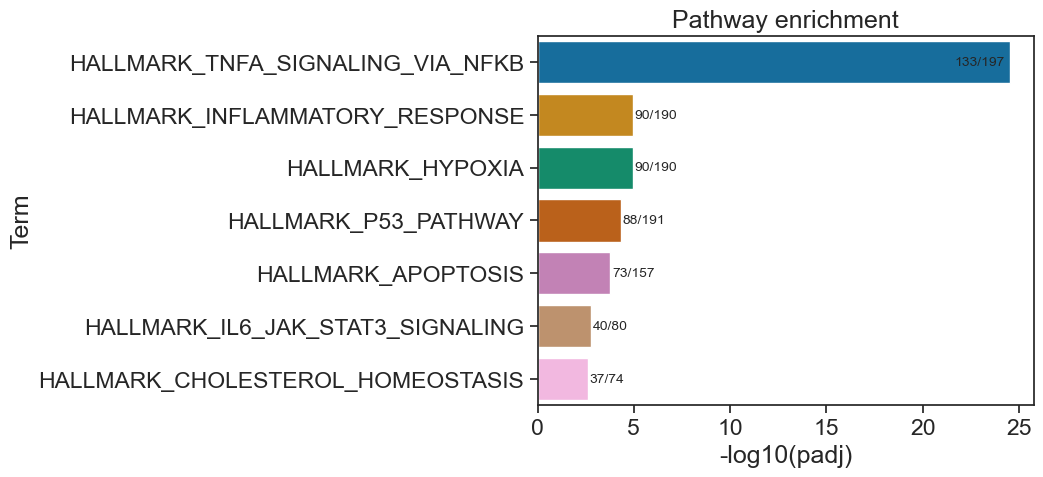

In [63]:
path_res = enr_res.results
path_res = path_res.sort_values('Adjusted P-value').reset_index(drop=True)

path_res['count'] = path_res.Overlap.str.split('/').str[0].astype(int) / path_res.Overlap.str.split('/').str[1].astype(int)
path_res['-log10(padj)'] = -np.log10(path_res['Adjusted P-value'])
path_res_sig = path_res[path_res['P-value'] < 0.05]

# Barplot
g = sns.barplot(data=path_res_sig.iloc[:7,:], y='Term', x='-log10(padj)', 
                   palette=sns.color_palette('colorblind'), orient='h')

# Annotate bars with Overlap values
for i, (bar, overlap) in enumerate(zip(g.patches, path_res_sig.iloc[:7]['Overlap'])):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if i == 0:
        width = width - 3
    g.text(width + 0.1, y, overlap, va='center', ha='left', fontsize=10)

plt.title('Pathway enrichment')
plt.savefig(f'figures/HM_liver_rna_pathway_enrichment.pdf', bbox_inches='tight', dpi=300)
#plt.show()

In [64]:
# Extract genes in each pathway
pathway_genes = {}
for row in path_res_sig.iterrows():
    genes = set(row[1]['Genes'].split(';'))
    path = row[1]['Term']
    pathway_genes[path] = genes

In [65]:
# # Add Gene Names back
    
# df_t_n = df_t.reset_index(names='Geneid').copy()
    
# df_t_n['Gene'] = df_t_n['Geneid'].map(loaded_dict)
# df_t_n.Gene = df_t_n.Gene.replace('', np.nan)
# df_t_n['Gene'] = np.where(df_t_n.Gene.isnull(), df_t_n.Geneid, df_t_n.Gene)
# df_t_n.index = df_t_n.Geneid
# df_t_n = df_t_n.drop('Geneid', axis=1)

Text(0.5, 0, 'log2FoldChange')

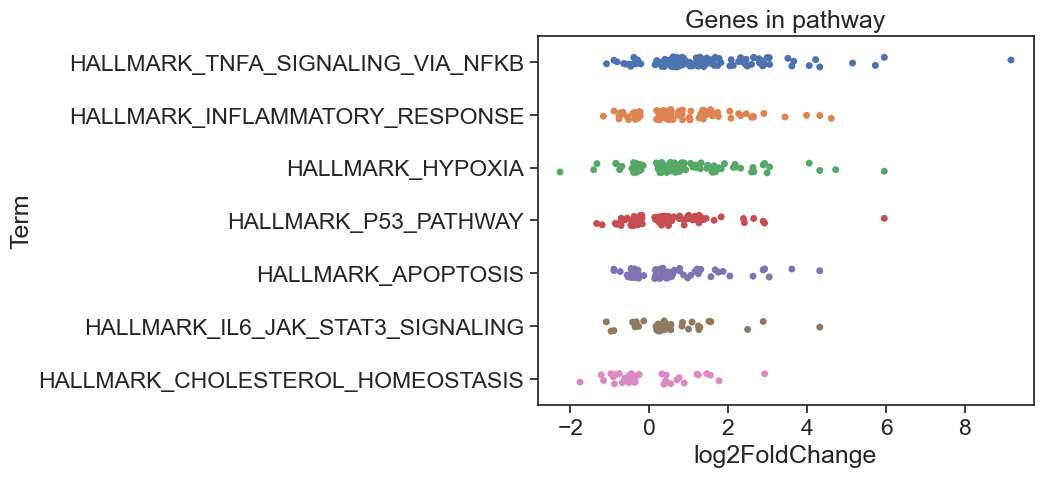

In [66]:
# Plot fold-change of genes identified in pathway enrichment

genes_list = []
for i in range(0,7):
    path = path_res_sig.Term[i]
    genes = pathway_genes[path]

    gene_data = df_sig_l[df_sig_l.Gene.isin(genes)].log2FoldChange
    genes_list.append(gene_data)
    
df_path_genes = pd.concat(genes_list, axis=1)
df_path_genes.columns = path_res_sig.Term[0:7]
df_path_genes.head()

sns.stripplot(data=df_path_genes, orient='h')
plt.title('Genes in pathway')
plt.xlabel('log2FoldChange')
#plt.savefig(f'figures/HM_liver_rna_pathway_FC.pdf', bbox_inches='tight', dpi=300)

In [67]:
df_path_genes.head()

Term,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_INFLAMMATORY_RESPONSE,HALLMARK_HYPOXIA,HALLMARK_P53_PATHWAY,HALLMARK_APOPTOSIS,HALLMARK_IL6_JAK_STAT3_SIGNALING,HALLMARK_CHOLESTEROL_HOMEOSTASIS
Geneid,,,,,,,
ENSG00000125740,9.166114,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000170345,5.955480,NaN,5.955480,5.95548,NaN,NaN,NaN
ENSG00000109321,5.730060,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000123358,5.151057,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000136244,4.320137,4.320137,4.320137,NaN,4.320137,4.320137,NaN


In [68]:
df_path_genes.isna()

Term,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_INFLAMMATORY_RESPONSE,HALLMARK_HYPOXIA,HALLMARK_P53_PATHWAY,HALLMARK_APOPTOSIS,HALLMARK_IL6_JAK_STAT3_SIGNALING,HALLMARK_CHOLESTEROL_HOMEOSTASIS
Geneid,,,,,,,
ENSG00000125740,False,True,True,True,True,True,True
ENSG00000170345,False,True,False,False,True,True,True
ENSG00000109321,False,True,True,True,True,True,True
ENSG00000123358,False,True,True,True,True,True,True
ENSG00000136244,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...
ENSG00000137449,True,True,True,True,True,True,False
ENSG00000104823,True,True,True,True,True,True,False
ENSG00000164211,True,True,True,True,True,True,False


In [69]:
# Create output csv file

# Populate export table with pathway gene identity

hm_dict = {}

for row in path_res.iterrows():
    term = row[1][1]
    genes = row[1]['Genes'].split(';')
    for gene in genes:
        if gene in hm_dict.keys():
            prev_term = hm_dict[gene]
            prev_term.append(term)
            hm_dict[gene] = prev_term
        else:
            hm_dict[gene] = [term]
            
df_ttest_['Hallmark'] = df_ttest_.Gene.map(hm_dict)
df_ttest_.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue,Hallmark
Geneid,,,,,,,,,,,
ENSG00000125740,840.911837,9.166114,0.473588,19.354625,1.863440e-83,7.324715e-80,9.166114,FOSB,positive,82.729685,"[HALLMARK_TNFA_SIGNALING_VIA_NFKB, HALLMARK_UV..."
ENSG00000170345,5716.198043,5.955480,0.381263,15.620413,5.286235e-55,1.038943e-51,5.955480,FOS,positive,54.276854,"[HALLMARK_TNFA_SIGNALING_VIA_NFKB, HALLMARK_HY..."
ENSG00000109321,32.868382,5.730060,0.728721,7.863170,3.745326e-15,4.749013e-13,5.730060,AREG,positive,14.426510,"[HALLMARK_TNFA_SIGNALING_VIA_NFKB, HALLMARK_ES..."
ENSG00000123358,311.474553,5.151057,0.333869,15.428389,1.054699e-53,1.842558e-50,5.151057,NR4A1,positive,52.976872,"[HALLMARK_TNFA_SIGNALING_VIA_NFKB, HALLMARK_UV..."
ENSG00000146678,14639.041145,4.723085,0.435767,10.838551,2.260234e-27,1.064461e-24,4.723085,IGFBP1,positive,26.645847,"[HALLMARK_HYPOXIA, HALLMARK_XENOBIOTIC_METABOL..."


In [70]:
df_liver_out = pd.concat([df_liver, df_ttest_], axis=1)
df_liver_out.head()

,BSSE_QGF_129466,BSSE_QGF_182052,BSSE_QGF_145476,BSSE_QGF_145472,BSSE_QGF_129476,BSSE_QGF_182072,BSSE_QGF_182064,BSSE_QGF_129474,BSSE_QGF_145460,BSSE_QGF_182054,...,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue,Hallmark
ENSG00000160072,7.628677,7.220001,7.157348,7.057075,7.795695,7.794800,7.907571,7.261420,7.747785,7.717703,...,0.093542,0.122348,0.764555,0.444537,0.598294,0.093542,ATAD3B,no,0.352093,NaN
ENSG00000142611,5.768085,5.059225,4.347859,5.092045,6.565460,4.967678,4.640026,5.477991,6.177095,4.643611,...,0.200011,0.367767,0.543853,0.586543,0.720487,0.200011,PRDM16,no,0.231700,NaN
ENSG00000157911,7.655978,7.186387,7.603541,8.785904,7.243597,8.304344,8.260630,7.970926,7.619202,8.255398,...,-0.591115,0.153434,-3.852556,0.000117,0.001011,0.591115,PEX10,negative,3.932218,NaN
ENSG00000142655,8.628060,8.388120,8.684634,9.166289,8.352413,8.970732,8.782465,8.872192,8.429772,8.515360,...,-0.268617,0.106888,-2.513078,0.011968,0.041285,0.268617,PEX14,negative,1.921968,"[HALLMARK_UV_RESPONSE_DN, HALLMARK_ADIPOGENESI..."
ENSG00000149527,6.847492,5.647802,5.967643,5.704994,6.369002,6.500375,7.658777,7.456830,6.308577,5.770824,...,-0.497611,0.241018,-2.064627,0.038958,0.102569,0.497611,PLCH2,no,1.409400,NaN


In [71]:
df_liver_out.to_csv('RNA_liver_output_05122025.csv')

# HCC

In [72]:
metadata_hcc.columns

Index(['Sample_type', 'Sex', 'Age', 'Tissue', 'Seq_id', 'patient_id', 'batch',
       'Time between resection and biopsy', 'Total surgery time'],
      dtype='object')

In [73]:
df_pc_hcc = df_pc.loc[:,metadata_hcc.index].copy()

In [74]:
# Filtering

# Create a copy to work on
df_pc_hcc_f = df_pc_hcc.copy()

# Apply the filter criteria
for col in df_pc_hcc_f.columns:
    df_pc_hcc_f[col] = np.where(df_pc_hcc_f[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_pc_hcc_f['Keep'] = np.where(df_pc_hcc_f.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_pc_hcc_f[df_pc_hcc_f.Keep].index

# Return only the rows that were determined to be kept during fitting
df_pc_hcc_f = df_pc_hcc.loc[keep_indices_].copy()

In [75]:
df_pc_hcc_f.shape

(16575, 30)

In [76]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_hcc_f.T,
    metadata=metadata_hcc,
    # design_factors=[Sex + batch + patient_id], # Sex as covariate
    design="~patient_id + Sample_type",
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_hcc_f.T)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_hcc_f.T.index, columns=df_pc_hcc_f.T.columns
)
df_hcc = transformed_counts.T

Fitting size factors...
... done in 0.03 seconds.

Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization
Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 11.28 seconds.



In [77]:
df_hcc.head()

Seq_id,BSSE_QGF_129467,BSSE_QGF_182053,BSSE_QGF_145477,BSSE_QGF_145473,BSSE_QGF_129477,BSSE_QGF_182073,BSSE_QGF_182065,BSSE_QGF_129475,BSSE_QGF_145461,BSSE_QGF_182055,...,BSSE_QGF_182107,BSSE_QGF_182099,BSSE_QGF_129479,BSSE_QGF_145463,BSSE_QGF_182085,BSSE_QGF_182101,BSSE_QGF_55744,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182111
ENSG00000160072,8.087017,8.342778,9.721116,7.779847,7.964220,9.663918,9.444492,8.597433,8.313341,8.340976,...,9.845260,8.775350,8.280598,8.459959,7.821504,8.640016,8.484763,9.016673,7.743095,8.545999
ENSG00000142611,4.827391,4.810591,5.120588,5.172637,6.405881,5.586655,6.328679,5.301185,5.282743,5.524255,...,4.769393,4.861532,5.273470,4.786215,5.033445,6.483175,7.038581,7.163212,6.550232,4.979339
ENSG00000157911,7.876716,8.027148,8.389657,8.592955,7.096751,7.916985,8.601629,8.308721,8.222739,7.613065,...,7.553239,8.318455,8.243026,7.747719,7.252696,7.842979,7.390491,7.322635,8.407994,7.298453
ENSG00000142655,6.896657,8.729402,8.939685,9.433079,7.987384,9.142334,9.018697,9.000283,9.515011,8.187141,...,8.775230,9.148201,9.157156,9.243759,8.440416,7.251872,8.108142,7.780053,8.853196,6.910852
ENSG00000149527,5.957286,7.187998,9.744854,7.237911,8.518742,7.429149,7.379030,5.759340,6.279460,6.492262,...,7.077454,6.117985,5.027819,7.410964,5.561066,4.750092,5.738697,7.761748,4.990299,5.788127


In [78]:
df_hcc_pca = df_hcc.copy()
df_hcc_pca['expression_std'] = df_hcc_pca.std(axis=1)
df_hcc_pca = df_hcc_pca.sort_values('expression_std', ascending=False)
df_hcc_pca = df_hcc_pca.iloc[:500,:-1]
df_hcc_pca.head()

Seq_id,BSSE_QGF_129467,BSSE_QGF_182053,BSSE_QGF_145477,BSSE_QGF_145473,BSSE_QGF_129477,BSSE_QGF_182073,BSSE_QGF_182065,BSSE_QGF_129475,BSSE_QGF_145461,BSSE_QGF_182055,...,BSSE_QGF_182107,BSSE_QGF_182099,BSSE_QGF_129479,BSSE_QGF_145463,BSSE_QGF_182085,BSSE_QGF_182101,BSSE_QGF_55744,BSSE_QGF_182103,BSSE_QGF_182105,BSSE_QGF_182111
ENSG00000160868,9.543428,15.006075,13.393114,14.463017,16.930943,15.729927,11.859455,14.834049,9.940524,13.754529,...,17.127805,15.781195,15.728967,8.400435,9.241555,17.825369,7.310433,14.212548,16.430526,6.455370
ENSG00000147604,6.799071,14.756788,6.866513,6.708476,7.196574,14.242649,14.046246,7.953823,6.971926,13.849950,...,14.598914,14.825129,8.704142,6.903589,14.492379,15.121311,13.769279,15.232200,15.961835,16.416229
ENSG00000132693,17.196730,14.437772,14.662877,17.482184,14.578260,9.245244,15.729062,15.398744,19.283086,9.984118,...,10.818982,16.168434,14.552431,19.195683,12.474163,13.185900,14.947222,16.425957,7.328013,5.676852
ENSG00000177954,6.687564,14.475361,7.862925,7.043691,7.016900,14.387216,13.397591,6.762467,6.853886,13.659166,...,14.801040,13.945850,6.925951,6.469935,14.425402,15.312256,13.352786,14.527184,15.373697,16.176931
ENSG00000130649,11.434553,14.605548,13.568570,15.255284,16.707551,11.862390,10.440927,17.902493,17.295649,14.596475,...,9.580611,13.460495,19.317284,17.080265,15.277007,13.133563,8.100288,14.729117,16.962997,13.913450


In [79]:
# scaled data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_hcc_pca.T)

In [80]:
pca = PCA(n_components=20)

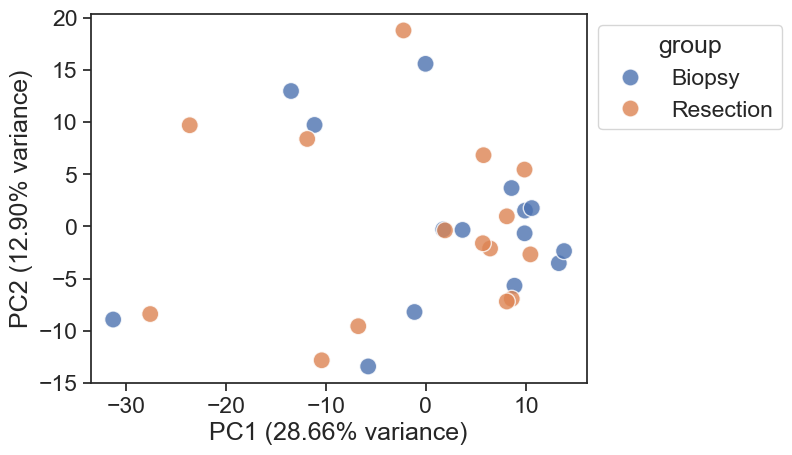

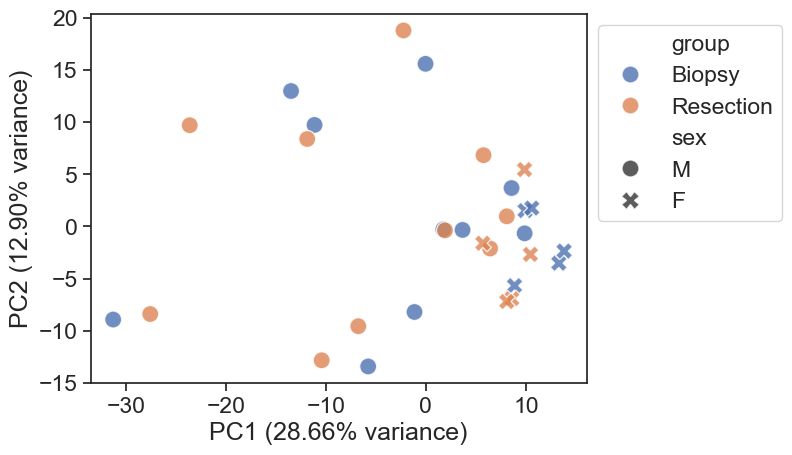

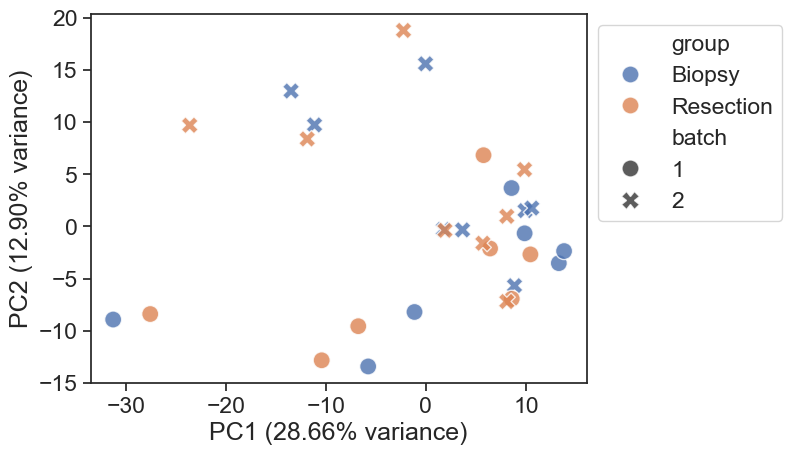

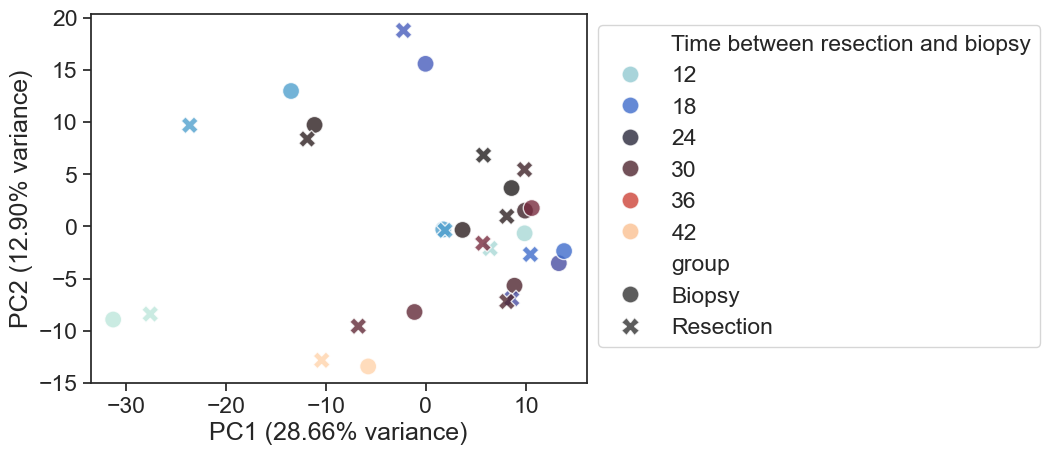

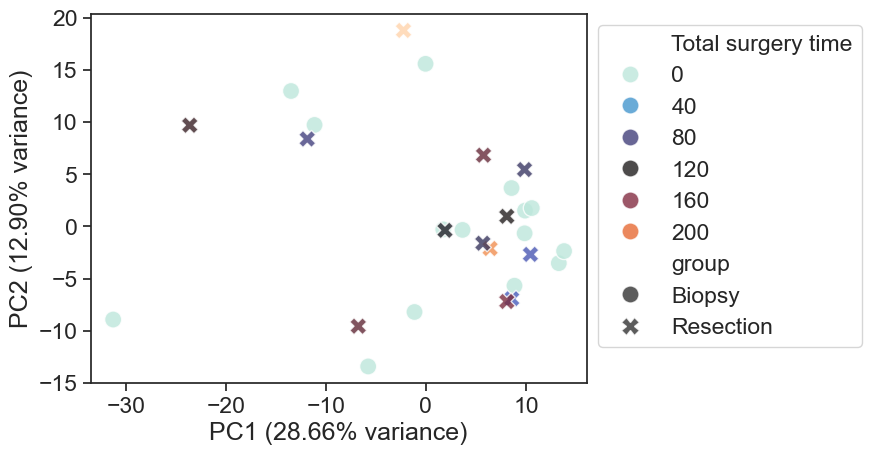

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_15788\3645965193.py:72: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y), hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


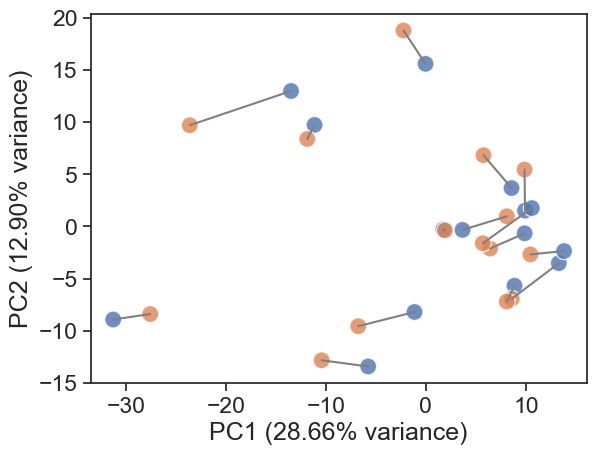

In [88]:
projections = pca.fit_transform(scaled_data)

pc_x = 1
pc_y = 2

df_pca = pd.DataFrame(projections, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5',
                                           'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
                                           'PC11', 'PC12', 'PC13', 'PC14', 'PC15',
                                           'PC16', 'PC17', 'PC18', 'PC19', 'PC20'], index=df_hcc_pca.columns)
df_pca['group'] = metadata_hcc.Sample_type
df_pca['batch'] = metadata_hcc.batch
df_pca['sex'] = metadata_hcc.Sex
df_pca['patient_id'] = metadata_hcc.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_hcc['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_hcc['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y), hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_pc{pc_y}.pdf', bbox_inches='tight', dpi=300)
#plt.show()

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y),style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
#plt.savefig('figures/PCA_hcc_sex.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Batch
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y),style='batch',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
#plt.savefig('figures/PCA_hcc_batch.pdf', bbox_inches='tight', dpi=300)
plt.show()


# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y), style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_timeBvR_pc{pc_y}.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y),style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_surgerytime_pc{pc_y}.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y), hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC' + str(pc_x), y='PC' + str(pc_y), hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC{str(pc_x)} ({pca.explained_variance_ratio_[pc_x -1]*100:.2f}% variance)')
plt.ylabel(f'PC{str(pc_y)} ({pca.explained_variance_ratio_[pc_y -1]*100:.2f}% variance)')
plt.savefig(f'figures/PCA_hcc_pat_pc{pc_y}.pdf', bbox_inches='tight', dpi=300)
#plt.show()


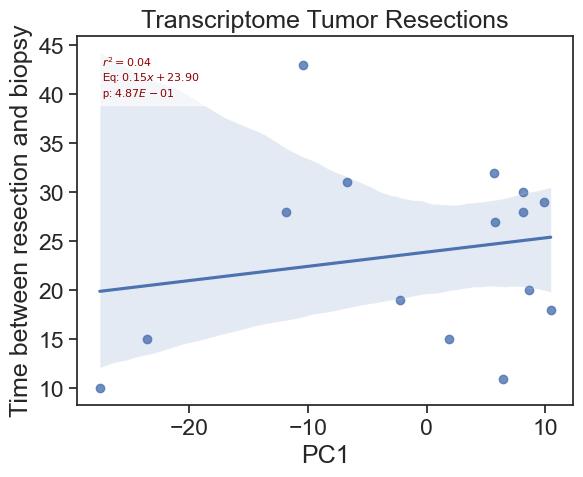

In [107]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Transcriptome Tumor Resections')


plt.savefig('figures/corr_pc1_time_b_to_r_tumor.pdf', dpi=300, bbox_inches='tight')

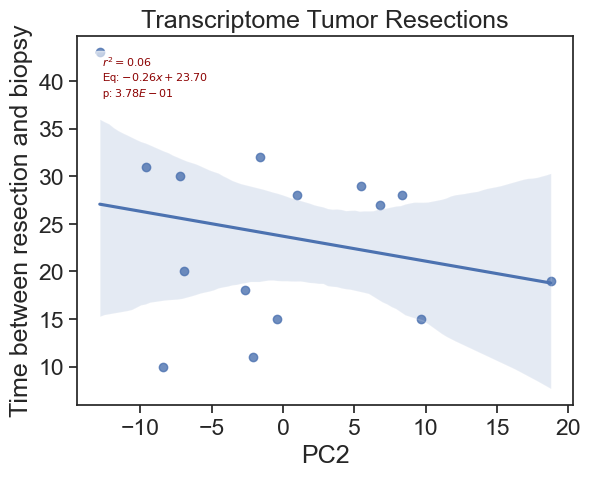

In [108]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Transcriptome Tumor Resections')


plt.savefig('figures/corr_pc2_time_b_to_r_tumor.pdf', dpi=300, bbox_inches='tight')

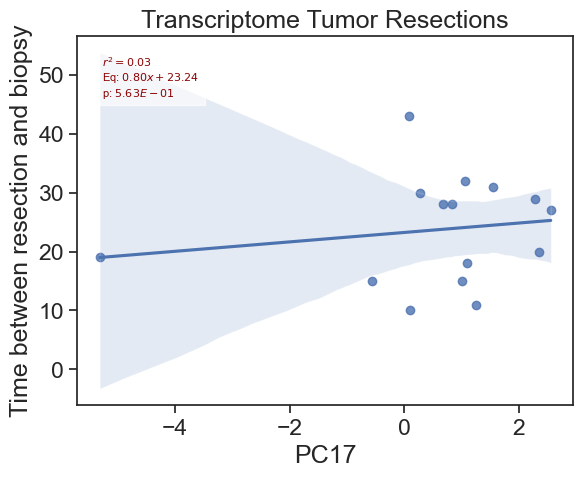

In [85]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC17', y='Time between resection and biopsy')
r2(df_pca_biop.PC17, df_pca_biop['Time between resection and biopsy'])

plt.title('Transcriptome Tumor Resections')


plt.savefig('figures/corr_pc17_time_b_to_r_tumor.pdf', dpi=300, bbox_inches='tight')

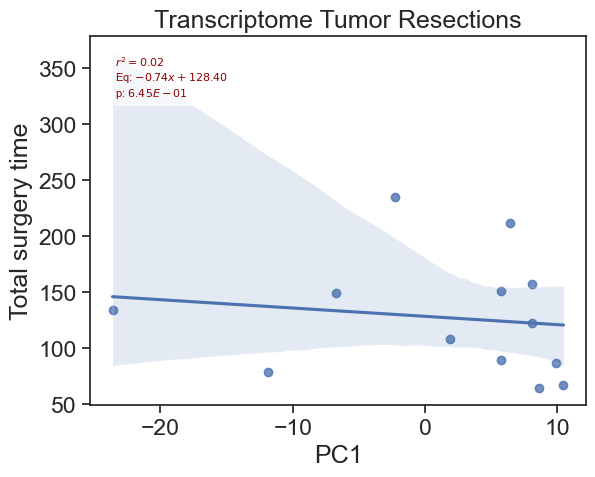

In [110]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Transcriptome Tumor Resections')

plt.savefig('figures/corr_pc1_time_surgery_tumor.pdf', dpi=300, bbox_inches='tight')

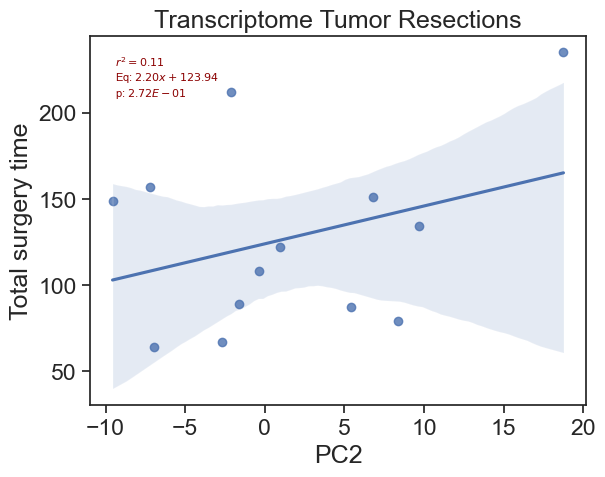

In [111]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Transcriptome Tumor Resections')

plt.savefig('figures/corr_pc2_time_surgery_tumor.pdf', dpi=300, bbox_inches='tight')

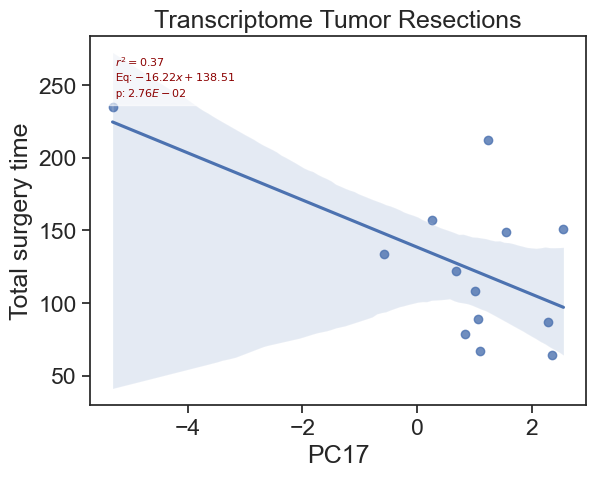

In [86]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC17', y='Total surgery time')
r2(df_pca_biop.PC17, df_pca_biop['Total surgery time'])

plt.title('Transcriptome Tumor Resections')

plt.savefig('figures/corr_pc17_time_surgery_tumor.pdf', dpi=300, bbox_inches='tight')

In [113]:
dds.vst()

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 11.47 seconds.



In [114]:
dds.deseq2(fit_type='parametric')

Using parametric fit type.
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 11.68 seconds.

Fitting dispersion trend curve...
... done in 0.67 seconds.

Fitting MAP dispersions...
... done in 13.25 seconds.

Fitting LFCs...
... done in 10.53 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 0 outlier genes.



In [115]:
# cooksCutoff=FALSE, independentFiltering=FALSE
ds = DeseqStats(dds, contrast=['Sample_type', 'Resection', 'Biopsy'],
                cooks_filter=False, independent_filter=False)

In [116]:
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Sample_type Resection vs Biopsy
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000160072  406.515174       -0.165295  0.142438 -1.160470  0.245858   
ENSG00000142611   32.464489       -0.339947  0.352419 -0.964610  0.334740   
ENSG00000157911  238.596948       -0.376704  0.125479 -3.002126  0.002681   
ENSG00000142655  370.736111       -0.203846  0.143775 -1.417812  0.156246   
ENSG00000149527  141.829329       -0.654149  0.268586 -2.435535  0.014870   
...                     ...             ...       ...       ...       ...   
ENSG00000278384   56.266587       -0.106878  0.214451 -0.498378  0.618218   
ENSG00000275063   47.546019       -1.049059  0.576045 -1.821141  0.068585   
ENSG00000277856   83.134217       -0.363205  0.855643 -0.424482  0.671214   
ENSG00000271254  213.327746       -0.195787  0.216919 -0.902579  0.366749   
ENSG00000277475    4.531083        0.186102  0.678716  0.274197  0.783934   

     

... done in 16.83 seconds.



In [117]:
df_res_hcc = ds.results_df
df_res_hcc['abs_diff'] = df_res_hcc.log2FoldChange.abs()
df_res_hcc = df_res_hcc.sort_values('abs_diff', ascending=False)
df_res_hcc.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff
ENSG00000125740,158.579162,3.807542,0.534962,7.117413,1.099717e-12,1.657073e-09,3.807542
ENSG00000090104,2014.544335,3.272291,0.310844,10.527102,6.479883e-26,1.074041e-21,3.272291
ENSG00000111704,2.640435,3.142276,1.146025,2.741891,6.108670e-03,4.849196e-02,3.142276
ENSG00000163736,20.605629,-3.035057,0.678552,-4.472845,7.718555e-06,1.037530e-03,3.035057
ENSG00000244734,7295.142570,-2.986662,0.416719,-7.167085,7.661119e-13,1.410923e-09,2.986662


In [118]:
# Add Gene Names
with open('../../../ensemble_mappings_gene.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_n_h = df_res_hcc.reset_index(names='Geneid').copy()
    
df_n_h['Gene'] = df_n_h['Geneid'].map(loaded_dict)
df_n_h.Gene = df_n_h.Gene.replace('', np.nan)
df_n_h['Gene'] = np.where(df_n_h.Gene.isnull(), df_n_h.Geneid, df_n_h.Gene)
df_n_h.index = df_n_h.Geneid
df_n_h = df_n_h.drop('Geneid', axis=1)

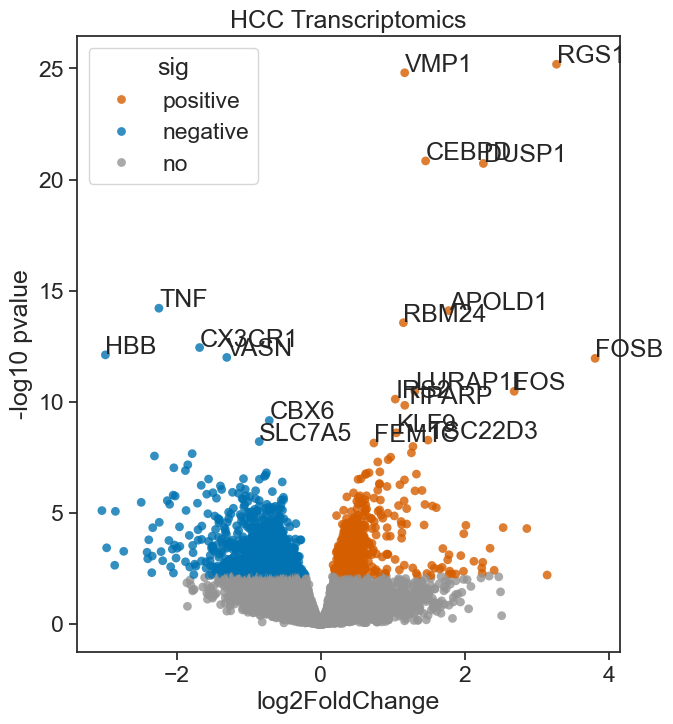

In [163]:
df_ttest_ = df_n_h.copy()

# Drop non-significant outlier
#df_ttest_ = df_ttest_[df_ttest_.Gene != 'SERPINB7']

df_ttest_['sig'] = np.where((df_ttest_['padj'] < 0.05) &\
                            (df_ttest_['log2FoldChange'] > 0), 'positive',
                    np.where((df_ttest_['padj'] < 0.05) &\
                             (df_ttest_['log2FoldChange'] < 0), 'negative', 
                                    'no'))
df_ttest_['-log10 pvalue'] = -np.log10(df_ttest_.pvalue)

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='log2FoldChange', y='-log10 pvalue',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pvalue', ascending=False)
                
most_sig['Gene'] = most_sig.index.map(loaded_dict)

for i in range(0,20):
    x = most_sig.iloc[i,:]['log2FoldChange'].item()
    y = most_sig.iloc[i,:]['-log10 pvalue'].item() + 0.05
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('HCC Transcriptomics')
#plt.show()
plt.savefig('figures/Volcano_rnaseq_hcc_output.pdf', bbox_inches='tight', dpi=300)

Text(0.5, 0, 'FOSB')

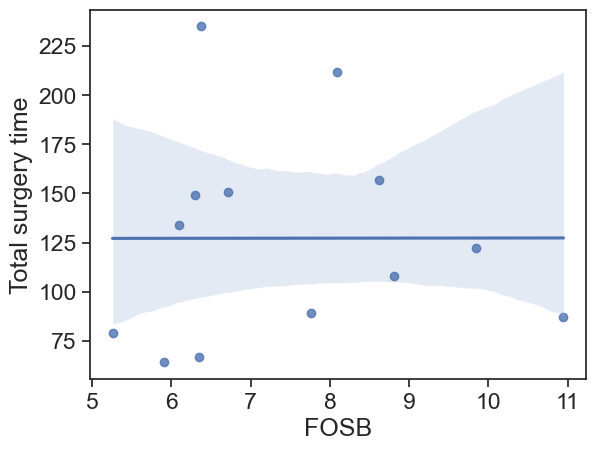

In [141]:
corr_times = pd.concat([df_hcc.loc['ENSG00000125740',:], metadata_hcc['Total surgery time']], axis=1)

corr_times = corr_times[corr_times['Total surgery time'] > 0]
sns.regplot(corr_times, x='ENSG00000125740', y='Total surgery time')
plt.xlabel('FOSB')

#plt.savefig('figures/FOSB_corr_surgery_time_hcc.pdf', dpi=300, bbox_inches='tight')

Text(0.5, 0, 'FOS')

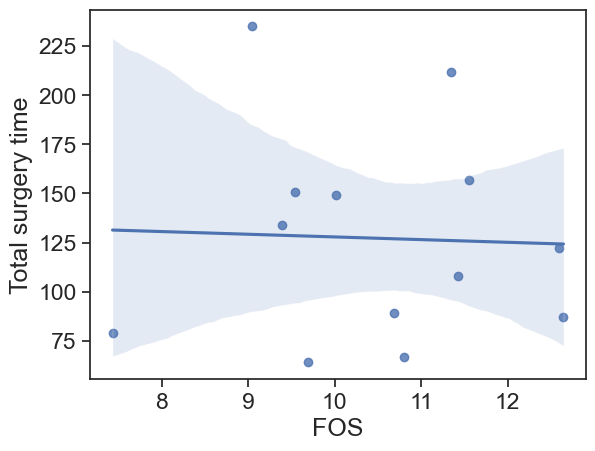

In [142]:
corr_times = pd.concat([df_hcc.loc['ENSG00000170345',:], metadata_hcc['Total surgery time']], axis=1)

corr_times = corr_times[corr_times['Total surgery time'] > 0]
sns.regplot(corr_times, x='ENSG00000170345', y='Total surgery time')
plt.xlabel('FOS')

#plt.savefig('figures/FOS_corr_surgery_time_hcc.pdf', dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'VST expression VS total surgery time')

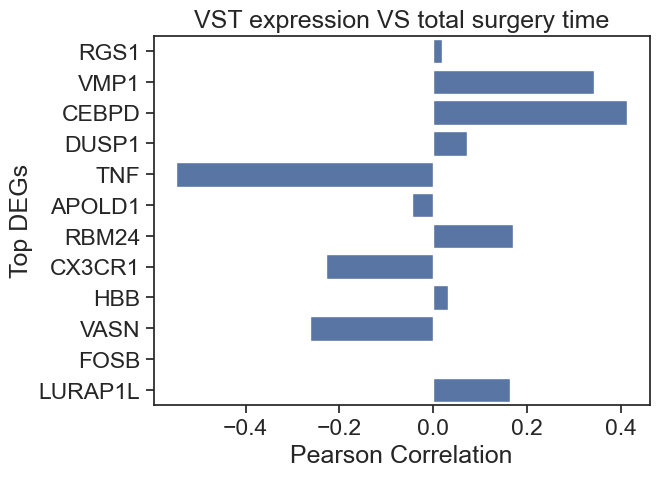

In [143]:
corr_times = pd.concat([df_hcc.loc[most_sig.iloc[:12,:].index,:].T, metadata_hcc['Total surgery time']], axis=1)
corr_times = corr_times[corr_times['Total surgery time'] > 0]

new_cols = corr_times.columns[:-1].map(loaded_dict).tolist()
new_cols.append('Total surgery time')
corr_times.columns = new_cols
sns.barplot(corr_times.corrwith(corr_times['Total surgery time'])[:-1], orient='h')
plt.ylabel('Top DEGs')
plt.xlabel('Pearson Correlation')
plt.title('VST expression VS total surgery time')

#plt.savefig('figures/top_degs_corr_surgery_time_hcc.pdf', dpi=300, bbox_inches='tight')

In [144]:
df_ttest_.sort_values('abs_diff', ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue
Geneid,,,,,,,,,,
ENSG00000125740,158.579162,3.807542,0.534962,7.117413,1.099717e-12,1.657073e-09,3.807542,FOSB,positive,11.958719
ENSG00000090104,2014.544335,3.272291,0.310844,10.527102,6.479883e-26,1.074041e-21,3.272291,RGS1,positive,25.188433
ENSG00000111704,2.640435,3.142276,1.146025,2.741891,6.108670e-03,4.849196e-02,3.142276,NANOG,positive,2.214053
ENSG00000163736,20.605629,-3.035057,0.678552,-4.472845,7.718555e-06,1.037530e-03,3.035057,PPBP,negative,5.112464
ENSG00000244734,7295.142570,-2.986662,0.416719,-7.167085,7.661119e-13,1.410923e-09,2.986662,HBB,negative,12.115708
...,...,...,...,...,...,...,...,...,...,...
ENSG00000106785,1084.519528,0.000072,0.096087,0.000750,9.994019e-01,9.998242e-01,0.000072,TRIM14,no,0.000260
ENSG00000198354,5.513785,0.000057,0.772727,0.000074,9.999410e-01,9.999410e-01,0.000057,DCAF12L2,no,0.000026
ENSG00000179934,21.304958,-0.000042,0.256393,-0.000164,9.998693e-01,9.999296e-01,0.000042,CCR8,no,0.000057


In [145]:
df_sig_h = df_ttest_[df_ttest_.padj < 0.05].copy()

In [146]:
msig = Msigdb()
gmt = msig.get_gmt(category='h.all', dbver="2024.1.Hs")

In [147]:
# Define background set as all identified protein codeing genes
bg_genes = set(df_n_h['Gene'])
len(bg_genes)

16573

In [148]:
enr_res = gp.enrichr(gene_list=df_sig_h.Gene.tolist(),
 gene_sets=gmt,
 organism='Homo Sapiens',
 outdir='HM/',
 background=bg_genes,
 )

In [149]:
enr_res.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,gs_ind_0,HALLMARK_ADIPOGENESIS,28/197,3.130650e-01,6.522188e-01,1.141563,1.325748,LAMA4;CAVIN1;ATL2;CHUK;ADIPOR2;ESRRA;MRPL15;PE...
1,gs_ind_0,HALLMARK_ALLOGRAFT_REJECTION,41/190,5.280752e-04,1.320188e-02,1.899037,14.330652,IFNG;CD40;FLNA;MRPL3;IFNAR2;CD7;STAB1;SPI1;RPL...
2,gs_ind_0,HALLMARK_ANDROGEN_RESPONSE,20/98,2.317422e-02,1.655301e-01,1.777541,6.691935,KRT19;PMEPA1;SPCS3;PLPP1;PIAS1;ELL2;B2M;SGK1;R...
3,gs_ind_0,HALLMARK_ANGIOGENESIS,3/34,8.307877e-01,9.912776e-01,0.752709,0.139538,STC1;JAG2;NRP1
4,gs_ind_0,HALLMARK_APICAL_JUNCTION,29/190,1.851838e-01,5.446581e-01,1.241436,2.093566,CX3CL1;PIK3CB;MAP4K2;EVL;ALOX15B;CLDN9;LDLRAP1...
5,gs_ind_0,HALLMARK_APICAL_SURFACE,7/43,3.124167e-01,6.522188e-01,1.394135,1.621961,SULF2;CROCC;CX3CL1;IL2RB;ADIPOR2;ADAM10;B4GALT1
6,gs_ind_0,HALLMARK_APOPTOSIS,26/159,1.159331e-01,4.140470e-01,1.349803,2.908477,PLPPR4;IRF1;BMF;DNAJC3;DNAJA1;GADD45B;NEDD9;FA...
7,gs_ind_0,HALLMARK_BILE_ACID_METABOLISM,11/110,8.519430e-01,9.912776e-01,0.782216,0.125339,PNPLA8;BCAR3;PEX13;FADS2;LIPE;RXRA;ABCA2;BMP6;...
8,gs_ind_0,HALLMARK_CHOLESTEROL_HOMEOSTASIS,12/74,2.372943e-01,6.522188e-01,1.357706,1.952998,CYP51A1;ERRFI1;ATF3;LSS;ECH1;FADS2;NFIL3;ATF5;...
9,gs_ind_0,HALLMARK_COAGULATION,10/134,9.832292e-01,9.912776e-01,0.569521,0.009632,PLEK;BMP1;LAMP2;CRIP2;PREP;CSRP1;PDGFB;MMP15;C...


C:\Users\Fredrik\AppData\Local\Temp\ipykernel_17588\339411021.py:9: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  g = sns.barplot(data=path_res_sig.iloc[:7,:], y='Term', x='-log10(padj)',


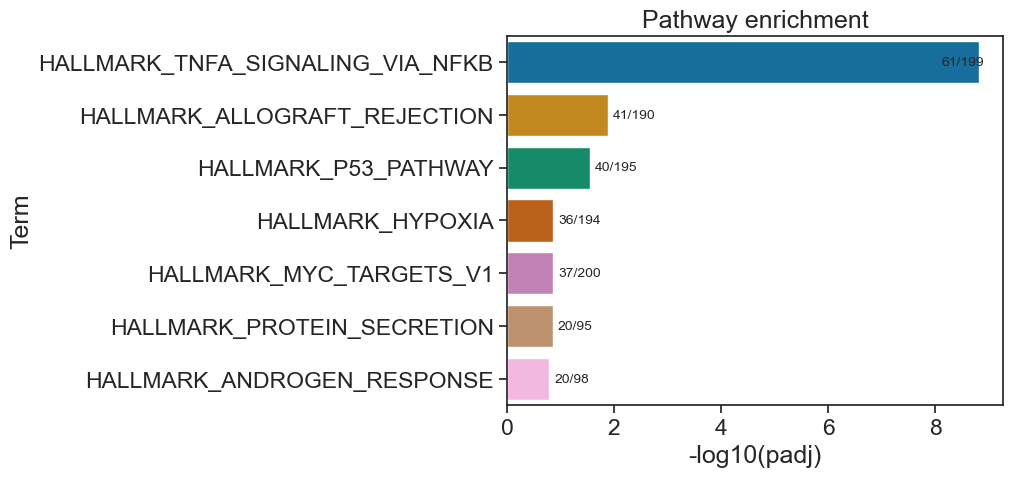

In [150]:
path_res = enr_res.results
path_res = path_res.sort_values('Adjusted P-value').reset_index(drop=True)

path_res['count'] = path_res.Overlap.str.split('/').str[0].astype(int) / path_res.Overlap.str.split('/').str[1].astype(int)
path_res['-log10(padj)'] = -np.log10(path_res['Adjusted P-value'])
path_res_sig = path_res[path_res['P-value'] < 0.05]

# Barplot
g = sns.barplot(data=path_res_sig.iloc[:7,:], y='Term', x='-log10(padj)', 
                   palette=sns.color_palette('colorblind'), orient='h')

# Annotate bars with Overlap values
for i, (bar, overlap) in enumerate(zip(g.patches, path_res_sig.iloc[:7]['Overlap'])):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if i == 0:
        width = width - .8
    g.text(width + 0.1, y, overlap, va='center', ha='left', fontsize=10)

plt.title('Pathway enrichment')
plt.savefig(f'figures/HM_hcc_rna_pathway_enrichment.pdf', bbox_inches='tight', dpi=300)
#plt.show()

In [151]:
# Extract genes in each pathway
pathway_genes = {}
for row in path_res_sig.iterrows():
    genes = set(row[1]['Genes'].split(';'))
    path = row[1]['Term']
    pathway_genes[path] = genes

Text(0.5, 0, 'log2FoldChange')

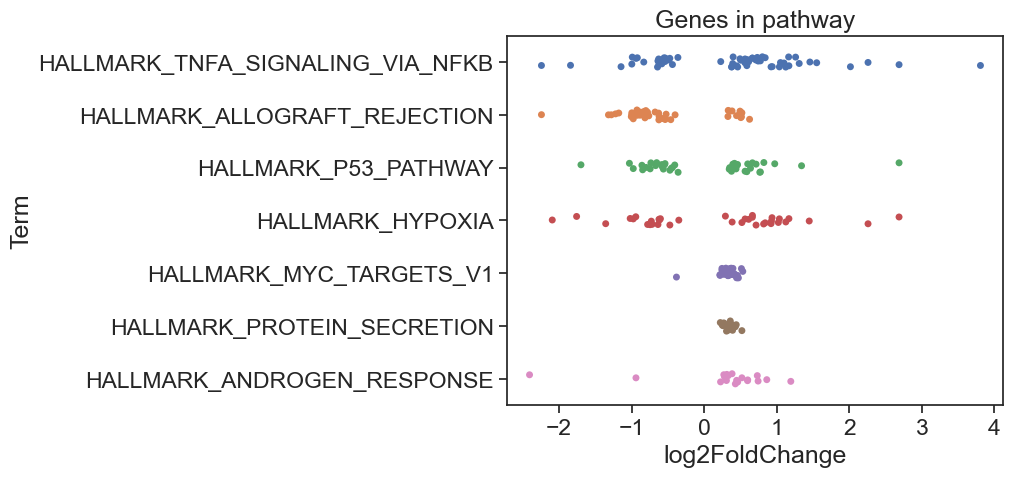

In [153]:
# Plot fold-change of genes identified in pathway enrichment

genes_list = []
for i in range(0,7):
    path = path_res_sig.Term[i]
    genes = pathway_genes[path]

    gene_data = df_sig_h[df_sig_h.Gene.isin(genes)].log2FoldChange
    genes_list.append(gene_data)
    
df_path_genes = pd.concat(genes_list, axis=1)
df_path_genes.columns = path_res_sig.Term[0:7]
#df_path_genes.head()

sns.stripplot(data=df_path_genes, orient='h')
plt.title('Genes in pathway')
plt.xlabel('log2FoldChange')
#plt.savefig(f'figures/HM_hcc_rna_pathway_FC.pdf', bbox_inches='tight', dpi=300)

In [154]:
df_path_genes.head()

Term,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_P53_PATHWAY,HALLMARK_HYPOXIA,HALLMARK_MYC_TARGETS_V1,HALLMARK_PROTEIN_SECRETION,HALLMARK_ANDROGEN_RESPONSE
Geneid,,,,,,,
ENSG00000125740,3.807542,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000170345,2.685365,NaN,2.685365,2.685365,NaN,NaN,NaN
ENSG00000120129,2.257792,NaN,NaN,2.257792,NaN,NaN,NaN
ENSG00000232810,-2.244320,-2.24432,NaN,NaN,NaN,NaN,NaN
ENSG00000109321,2.015039,NaN,NaN,NaN,NaN,NaN,NaN


In [155]:
# Create output csv file

# Populate export table with pathway gene identity

hm_dict = {}

for row in path_res.iterrows():
    term = row[1][1]
    genes = row[1]['Genes'].split(';')
    for gene in genes:
        if gene in hm_dict.keys():
            prev_term = hm_dict[gene]
            prev_term.append(term)
            hm_dict[gene] = prev_term
        else:
            hm_dict[gene] = [term]
            
df_ttest_['Hallmark'] = df_ttest_.Gene.map(hm_dict)
df_ttest_.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue,Hallmark
Geneid,,,,,,,,,,,
ENSG00000125740,158.579162,3.807542,0.534962,7.117413,1.099717e-12,1.657073e-09,3.807542,FOSB,positive,11.958719,"[HALLMARK_TNFA_SIGNALING_VIA_NFKB, HALLMARK_UV..."
ENSG00000090104,2014.544335,3.272291,0.310844,10.527102,6.479883e-26,1.074041e-21,3.272291,RGS1,positive,25.188433,[HALLMARK_INFLAMMATORY_RESPONSE]
ENSG00000111704,2.640435,3.142276,1.146025,2.741891,6.108670e-03,4.849196e-02,3.142276,NANOG,positive,2.214053,NaN
ENSG00000163736,20.605629,-3.035057,0.678552,-4.472845,7.718555e-06,1.037530e-03,3.035057,PPBP,negative,5.112464,[HALLMARK_KRAS_SIGNALING_UP]
ENSG00000244734,7295.142570,-2.986662,0.416719,-7.167085,7.661119e-13,1.410923e-09,2.986662,HBB,negative,12.115708,[HALLMARK_HEME_METABOLISM]


In [156]:
df_hcc_out = pd.concat([df_hcc, df_ttest_], axis=1)
df_hcc_out.head()

,BSSE_QGF_129467,BSSE_QGF_182053,BSSE_QGF_145477,BSSE_QGF_145473,BSSE_QGF_129477,BSSE_QGF_182073,BSSE_QGF_182065,BSSE_QGF_129475,BSSE_QGF_145461,BSSE_QGF_182055,...,log2FoldChange,lfcSE,stat,pvalue,padj,abs_diff,Gene,sig,-log10 pvalue,Hallmark
ENSG00000160072,8.087017,8.342778,9.721116,7.779847,7.964220,9.663918,9.444492,8.597433,8.313341,8.340976,...,-0.165295,0.142438,-1.160470,0.245858,0.454708,0.165295,ATAD3B,no,0.609316,NaN
ENSG00000142611,4.827391,4.810591,5.120588,5.172637,6.405881,5.586655,6.328679,5.301185,5.282743,5.524255,...,-0.339947,0.352419,-0.964610,0.334740,0.547820,0.339947,PRDM16,no,0.475292,NaN
ENSG00000157911,7.876716,8.027148,8.389657,8.592955,7.096751,7.916985,8.601629,8.308721,8.222739,7.613065,...,-0.376704,0.125479,-3.002126,0.002681,0.030813,0.376704,PEX10,negative,2.571702,NaN
ENSG00000142655,6.896657,8.729402,8.939685,9.433079,7.987384,9.142334,9.018697,9.000283,9.515011,8.187141,...,-0.203846,0.143775,-1.417812,0.156246,0.348116,0.203846,PEX14,no,0.806192,NaN
ENSG00000149527,5.957286,7.187998,9.744854,7.237911,8.518742,7.429149,7.379030,5.759340,6.279460,6.492262,...,-0.654149,0.268586,-2.435535,0.014870,0.081855,0.654149,PLCH2,no,1.827695,NaN


In [157]:
df_hcc_out.to_csv('RNA_hcc_output_04122025.csv')

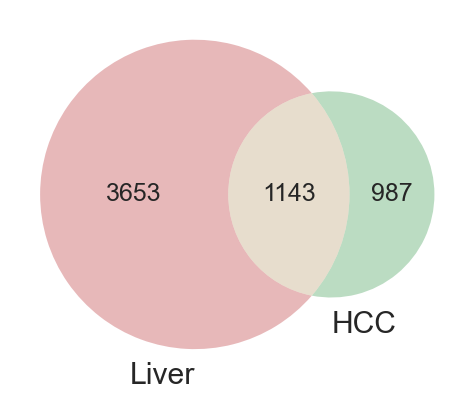

In [158]:
from matplotlib_venn import venn2

set1 = set(df_sig_l.Gene)
set2 = set(df_sig_h.Gene)

venn2([set1, set2], ('Liver', 'HCC'))

plt.savefig('figures/Venn_sig_degs_liver_vs_hcc.pdf', dpi=300, bbox_inches='tight')

In [159]:
df_sig_merge = df_sig_l.merge(df_sig_h, on='Gene', suffixes=('_liver', '_hcc'))

In [160]:
df_sig_merge.columns

Index(['baseMean_liver', 'log2FoldChange_liver', 'lfcSE_liver', 'stat_liver',
       'pvalue_liver', 'padj_liver', 'abs_diff_liver', 'Gene', 'sig_liver',
       '-log10 pvalue_liver', 'baseMean_hcc', 'log2FoldChange_hcc',
       'lfcSE_hcc', 'stat_hcc', 'pvalue_hcc', 'padj_hcc', 'abs_diff_hcc',
       'sig_hcc', '-log10 pvalue_hcc'],
      dtype='object')

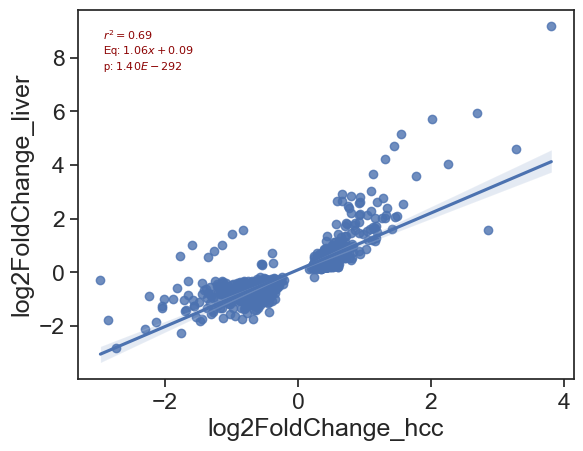

In [161]:
sns.regplot(df_sig_merge, x='log2FoldChange_hcc', y='log2FoldChange_liver' )

r2(df_sig_merge.log2FoldChange_hcc, df_sig_merge.log2FoldChange_liver)

plt.savefig('figures/Corr_sig_degs_liver_vs_hcc.pdf', dpi=300, bbox_inches='tight')